In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json

from pathlib import Path
import sys
project_root = Path.cwd() / "../../"
sys.path.append(str(project_root))

from utils.visualizations import (
    within_metric_barplot, within_metric_dotplot,
    multi_within_metric_barplot, multi_within_metric_dotplot,
    across_metric_barplot, across_metric_dotplot,
    few_shot_dev, multi_few_shot_dev
)

# **Data Loading**

In [8]:
# import all json files
with open("cross_val_results/evaluation_metrics_bert_stance_sequence.json", "r") as f:
    bert_results = json.load(f)

with open("cross_val_results/evaluation_metrics_dictionary_stance.json", "r") as f:
    dictionary_results = json.load(f)

with open("cross_val_results/evaluation_metrics_bert_stance_nli.json", "r") as f:
    nli_results = json.load(f)

with open("cross_val_results/evaluation_metrics_gen_llm_stance.json", "r") as f:
    gpt_results = json.load(f)

# combine all models
all_results = {**bert_results, **dictionary_results, **nli_results, **gpt_results}

# reorder the dictionaries
bert_results = dict(
    (k, bert_results[k]) for k in [
        'microsoft/deberta-v3-base',
        'roberta-base',
        'bert-base-cased',
        'distilbert-base-cased'
    ]
)
gpt_results = dict(
    (k, gpt_results[k]) for k in [
        'gpt-5-nano',
        'gpt-4o-mini'
    ]
)

all_results = dict(
    (k, all_results[k]) for k in [
        'MoritzLaurer/deberta-v3-base-zeroshot-v2.0',
        'microsoft/deberta-v3-base',
        'roberta-base',
        'bert-base-cased',
        'distilbert-base-cased',
        'dictionary',
        'gpt-5-nano',
        'gpt-4o-mini'
    ]
)

# **Model Comparisons Within Model Group**

## **Dictionary Baseline**

In [9]:
# define remapping dictionaries for plots
main_metrics_remap = {
    "negative": "Negative", "neutral": "Neutral", "positive": "Positive", "macro": "Macro"
}
model_names_remap = {
    "MoritzLaurer/deberta-v3-base-zeroshot-v2.0": "DeBERTa - NLI",
    "microsoft/deberta-v3-base": "DeBERTa",
    "roberta-base": "RoBERTa",
    "bert-base-cased": "BERT",
    "distilbert-base-cased": "DistilBERT",
    "dictionary": "Dictionary",
    "gpt-5-nano": "GPT-5-nano",
    "gpt-4o-mini": "GPT-4o-mini"
}

# all main metrics to look at
focus_metrics = ["negative", "neutral", "positive", "macro"]

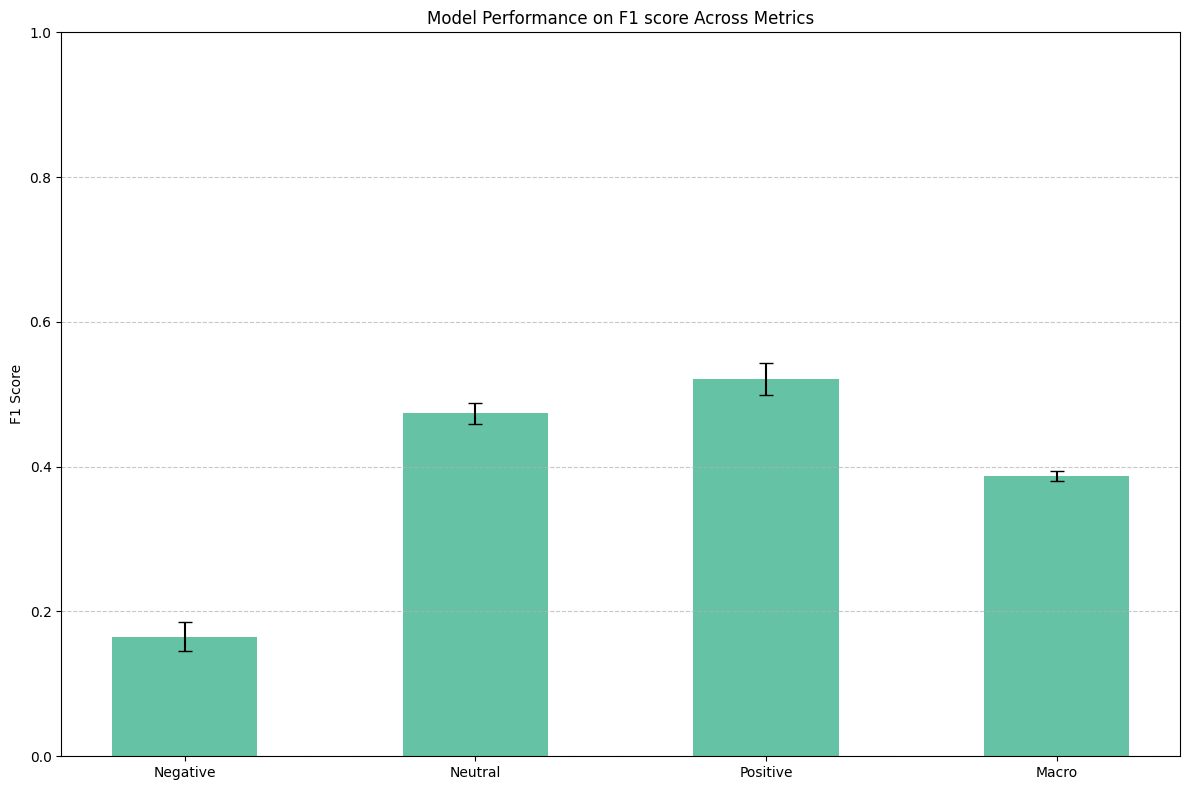

In [10]:
across_metric_barplot(
    eval_results=dictionary_results,
    focus_metrics=focus_metrics,
    comparison_metric="f1",
    main_metrics_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# across_metric_dotplot(
#     eval_results=dictionary_results,
#     focus_metrics=focus_metrics,
#     comparison_metric="f1",
#     main_metrics_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=0.3,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )

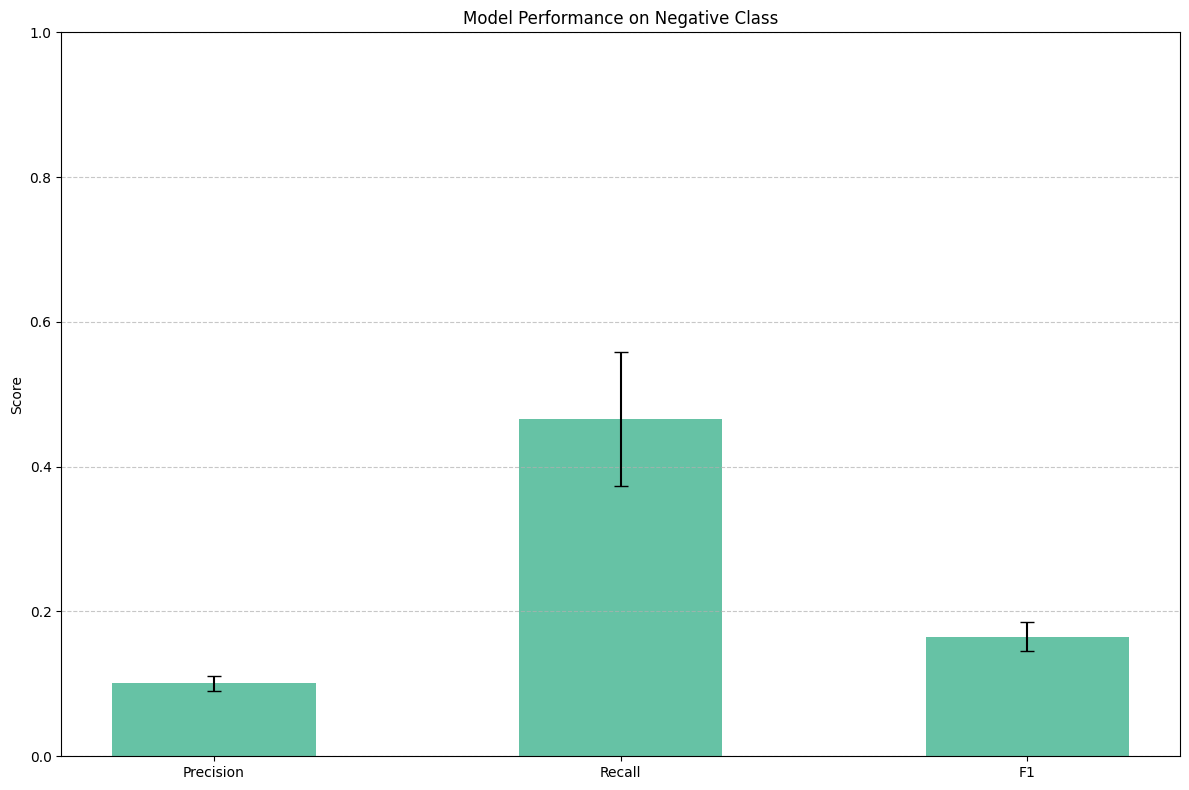

In [11]:
within_metric_barplot(
    eval_results=dictionary_results,
    focus_metrics=["negative"],
    metric_title_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# within_metric_dotplot(
#     eval_results=dictionary_results,
#     focus_metrics=["neutral"],
#     metric_title_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=0.3,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )

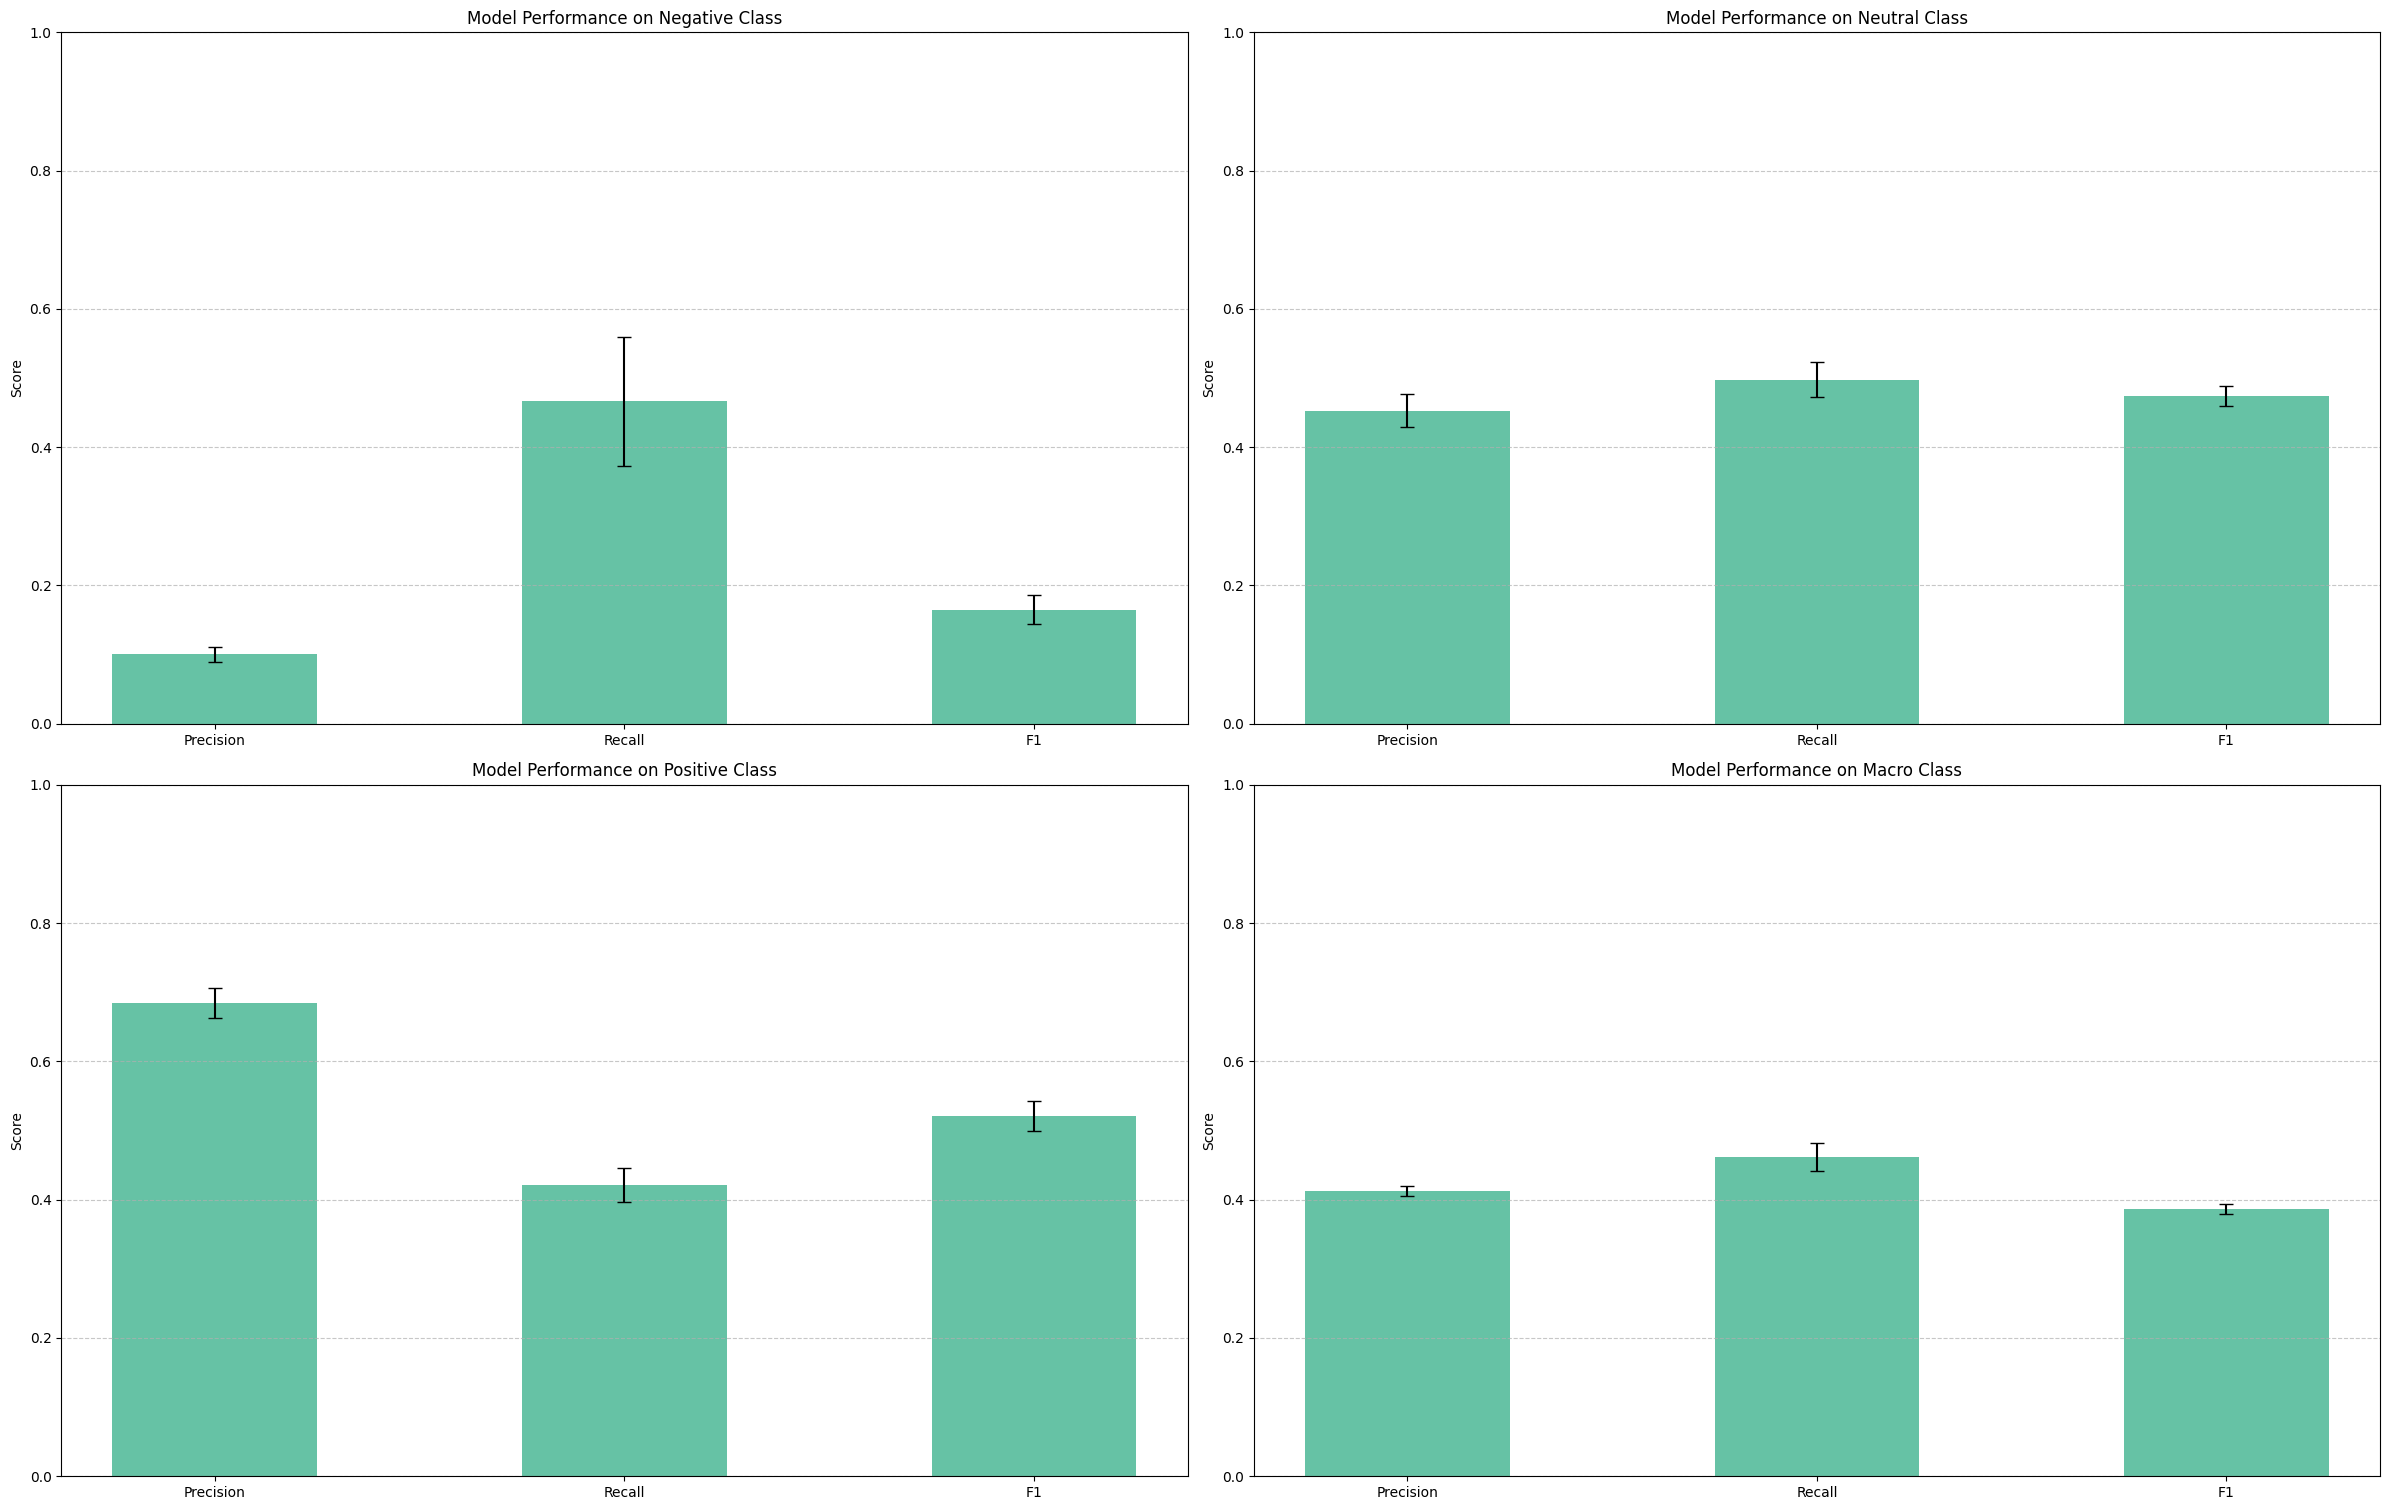

In [6]:
multi_within_metric_barplot(
    eval_results=dictionary_results,
    focus_metrics=focus_metrics,
    metric_title_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# multi_within_metric_dotplot(
#     eval_results=dictionary_results,
#     focus_metrics=focus_metrics,
#     metric_title_remap=main_metrics_remap, 
#     model_names_remap=model_names_remap,
#     group_width=1,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )

## **BERT Sequence Classification Models**

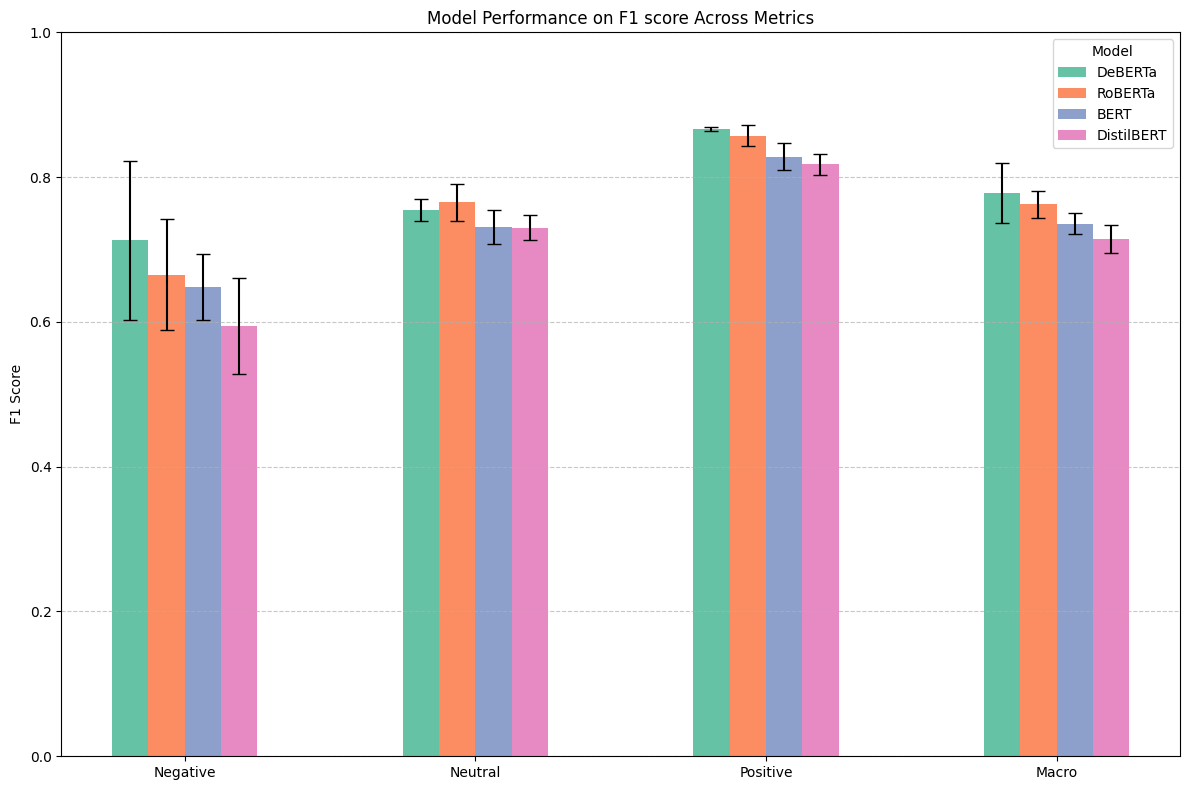

In [12]:
across_metric_barplot(
    eval_results=bert_results,
    focus_metrics=focus_metrics,
    comparison_metric="f1",
    main_metrics_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# across_metric_dotplot(
#     eval_results=bert_results,
#     focus_metrics=focus_metrics,
#     comparison_metric="f1",
#     main_metrics_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=0.3,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )

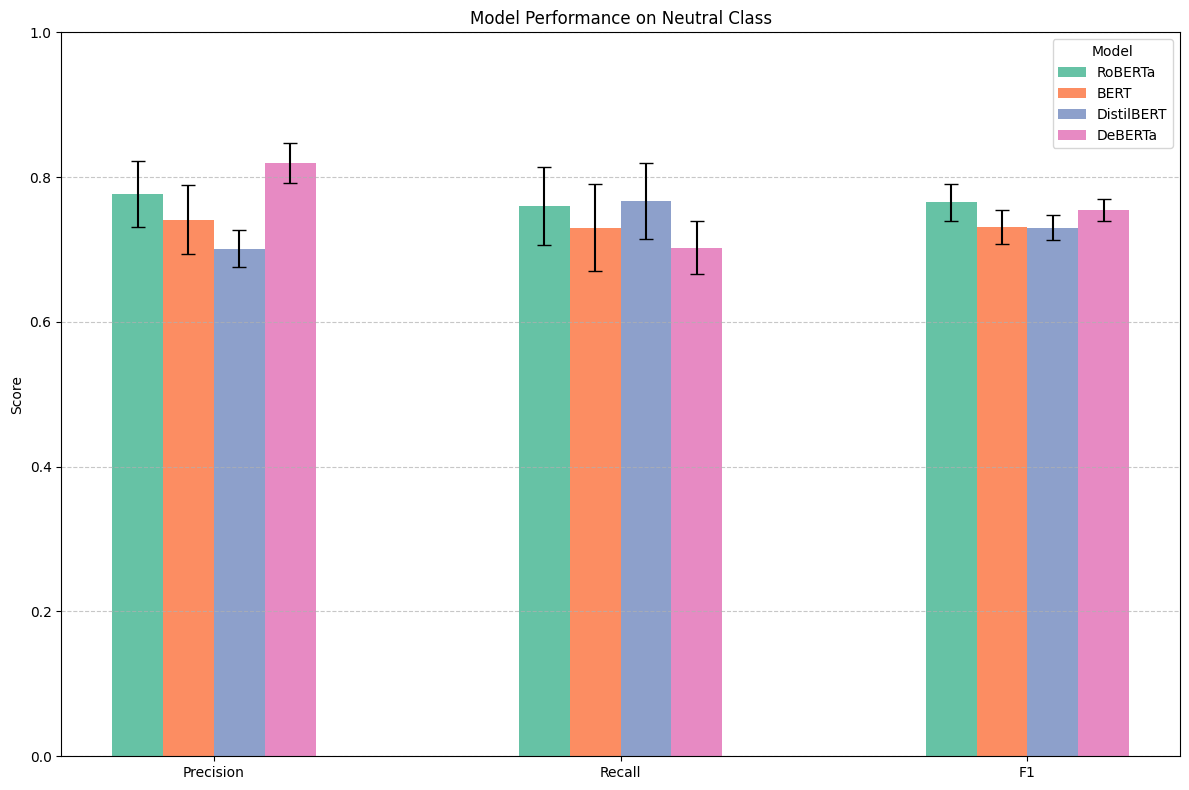

In [8]:
within_metric_barplot(
    eval_results=bert_results,
    focus_metrics=["neutral"],
    metric_title_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# within_metric_dotplot(
#     eval_results=bert_results,
#     focus_metrics=["neutral"],
#     metric_title_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=0.3,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )

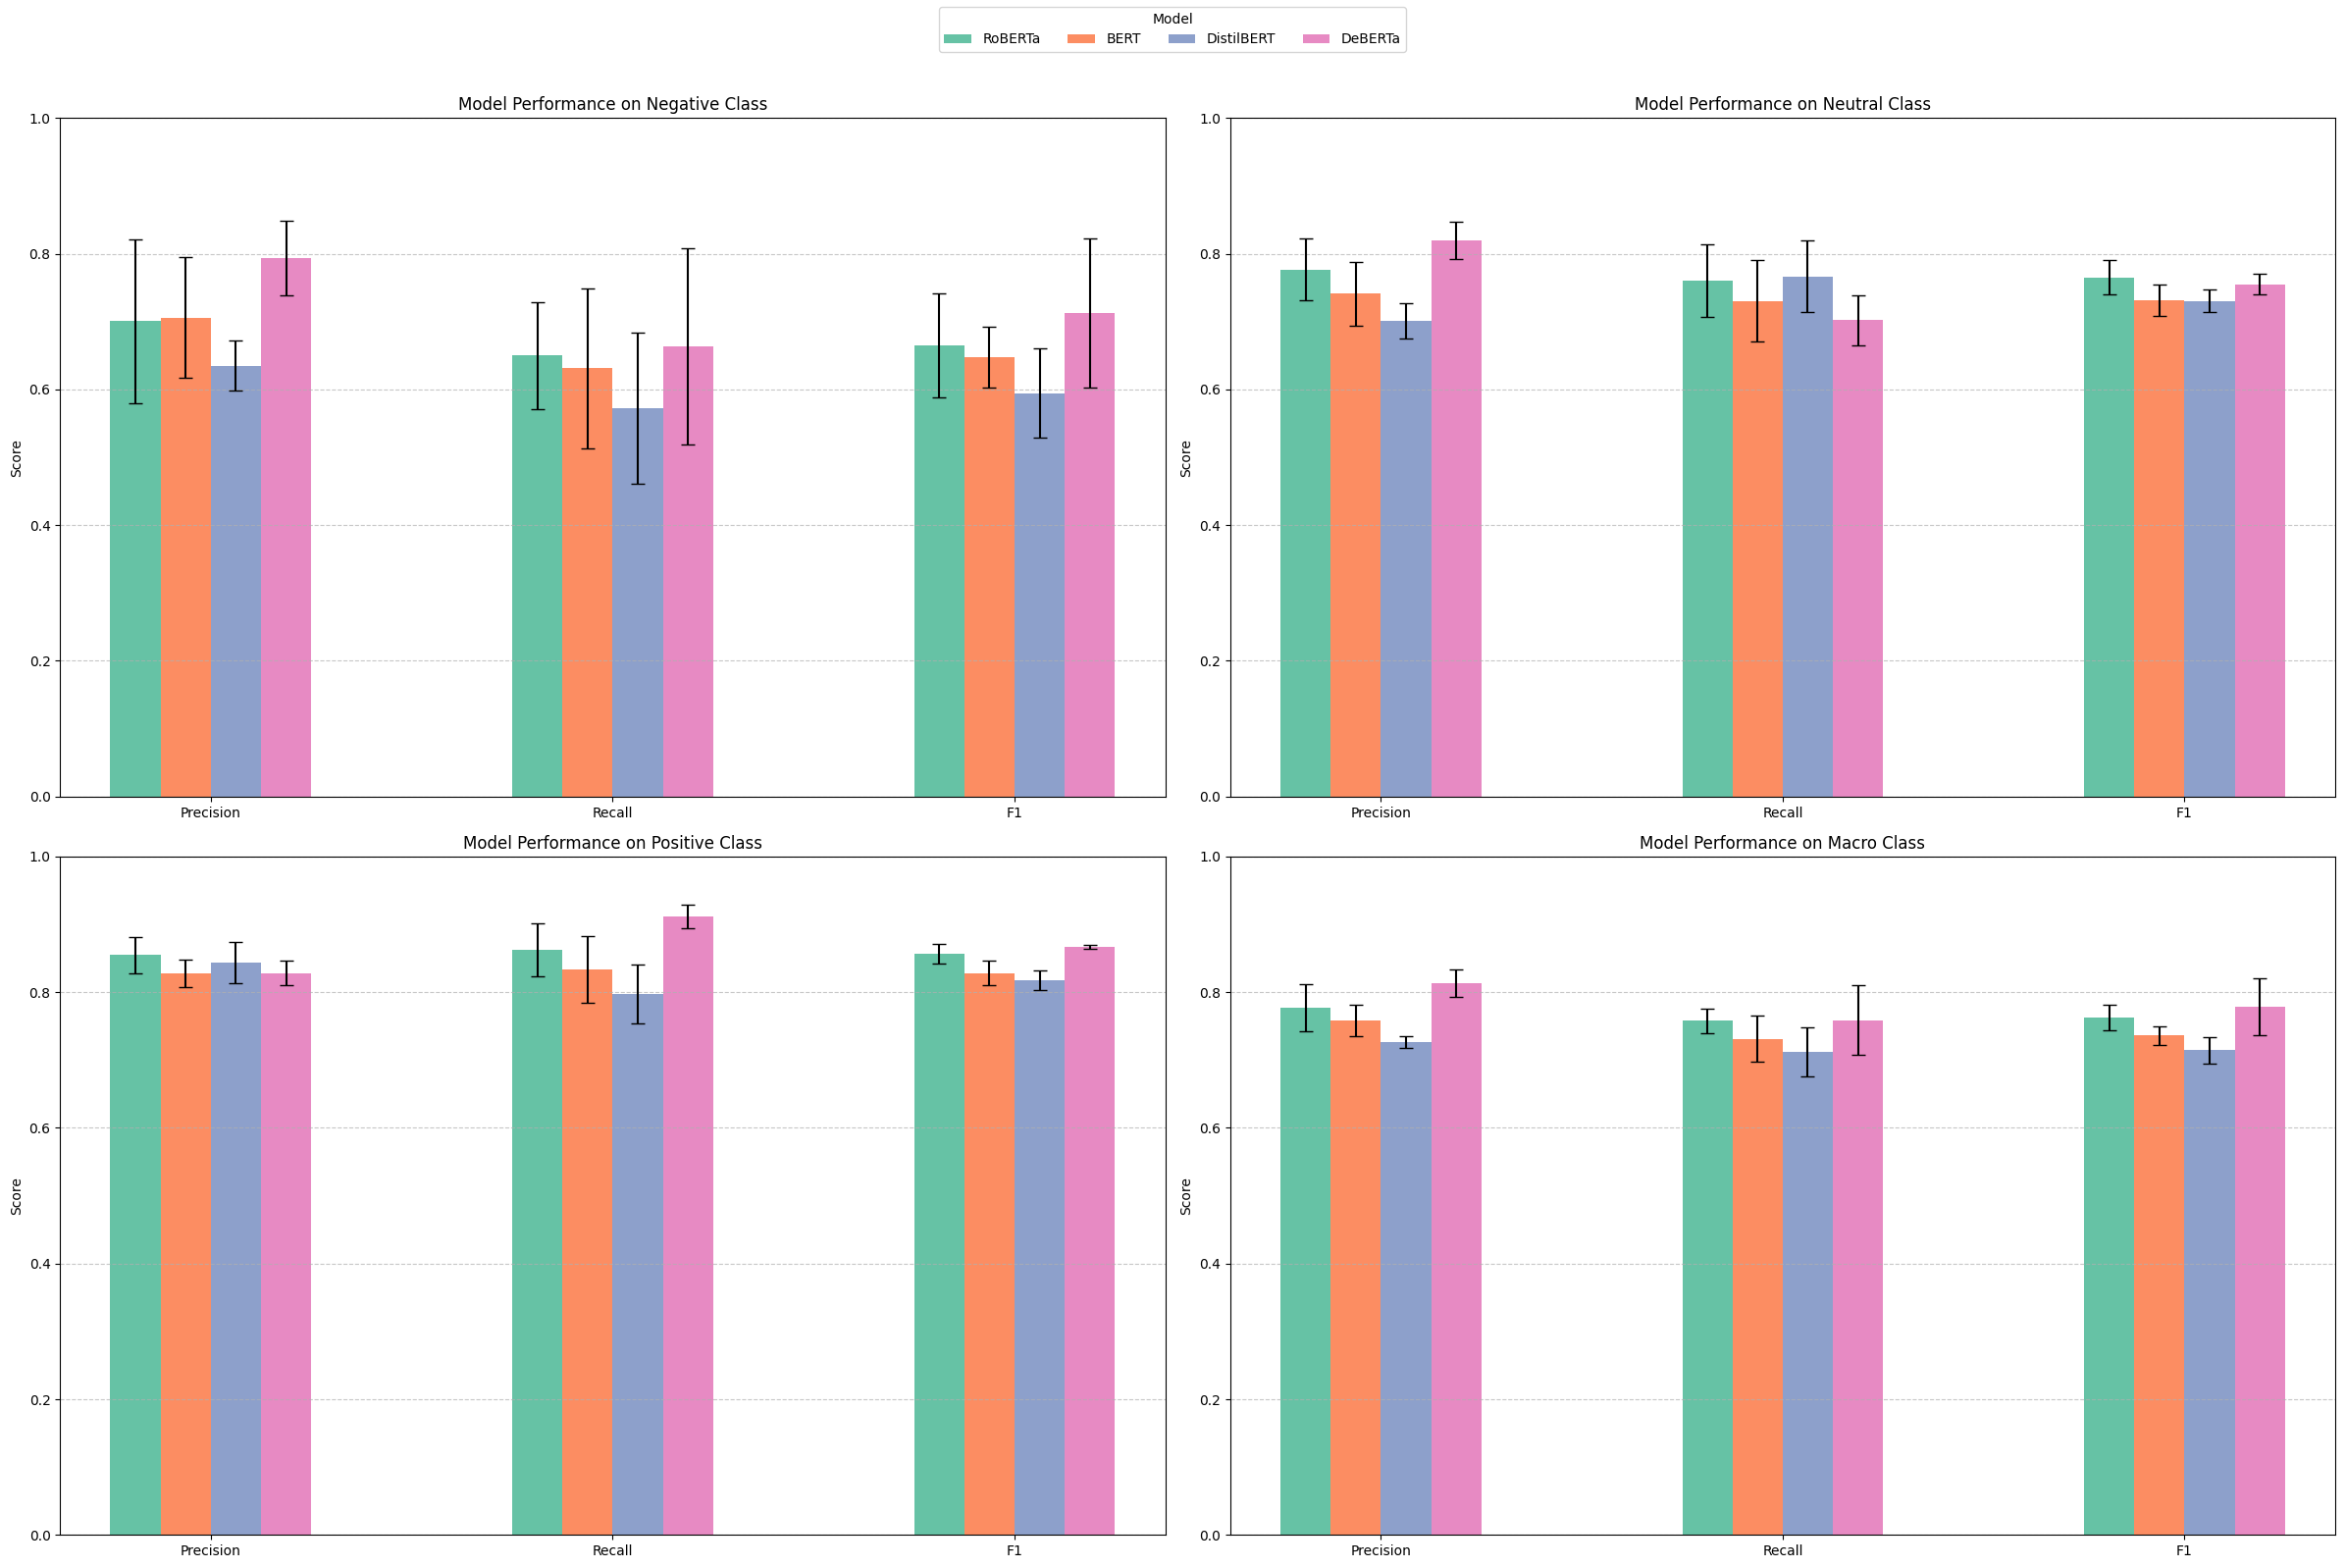

In [9]:
multi_within_metric_barplot(
    eval_results=bert_results,
    focus_metrics=focus_metrics,
    metric_title_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# multi_within_metric_dotplot(
#     eval_results=bert_results,
#     focus_metrics=focus_metrics,
#     metric_title_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=1,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )

## **BERT NLI Model**

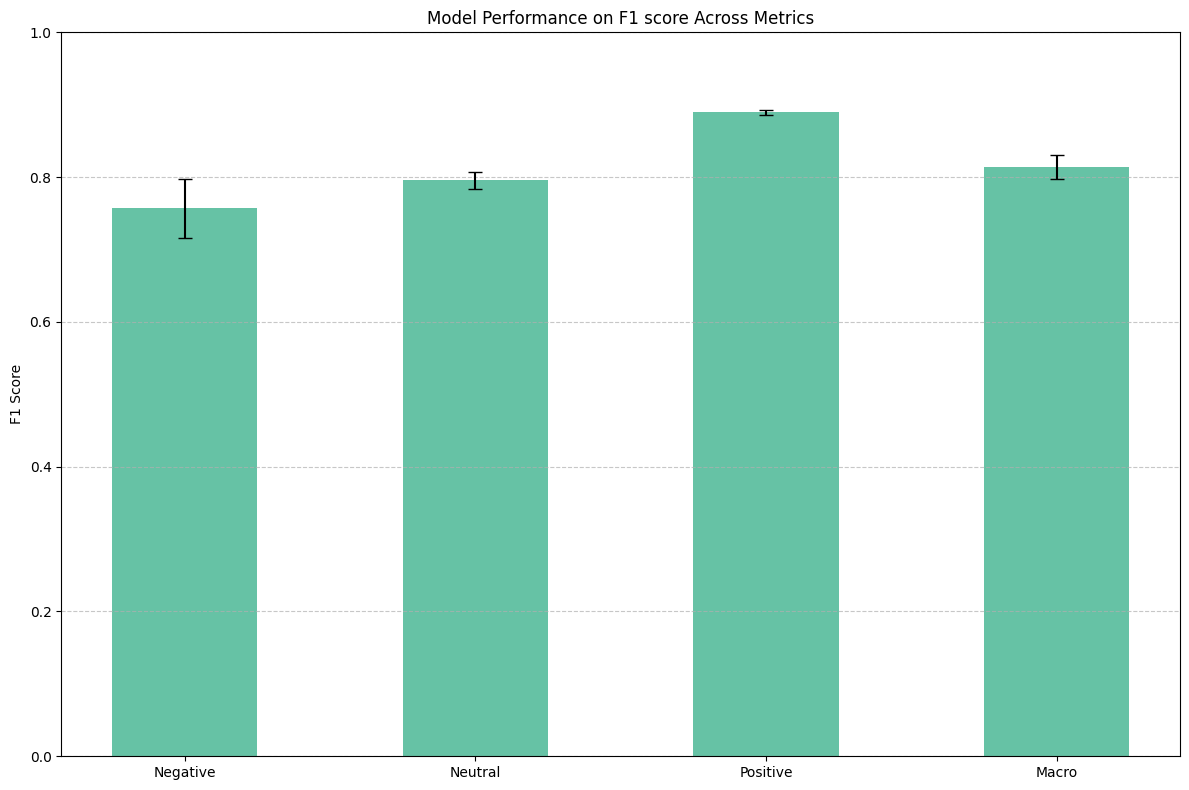

In [10]:
across_metric_barplot(
    eval_results=nli_results,
    focus_metrics=focus_metrics,
    comparison_metric="f1",
    main_metrics_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1]
)
# across_metric_dotplot(
#     eval_results=nli_results,
#     focus_metrics=focus_metrics,
#     comparison_metric="f1",
#     main_metrics_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=0.3,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1]
# )

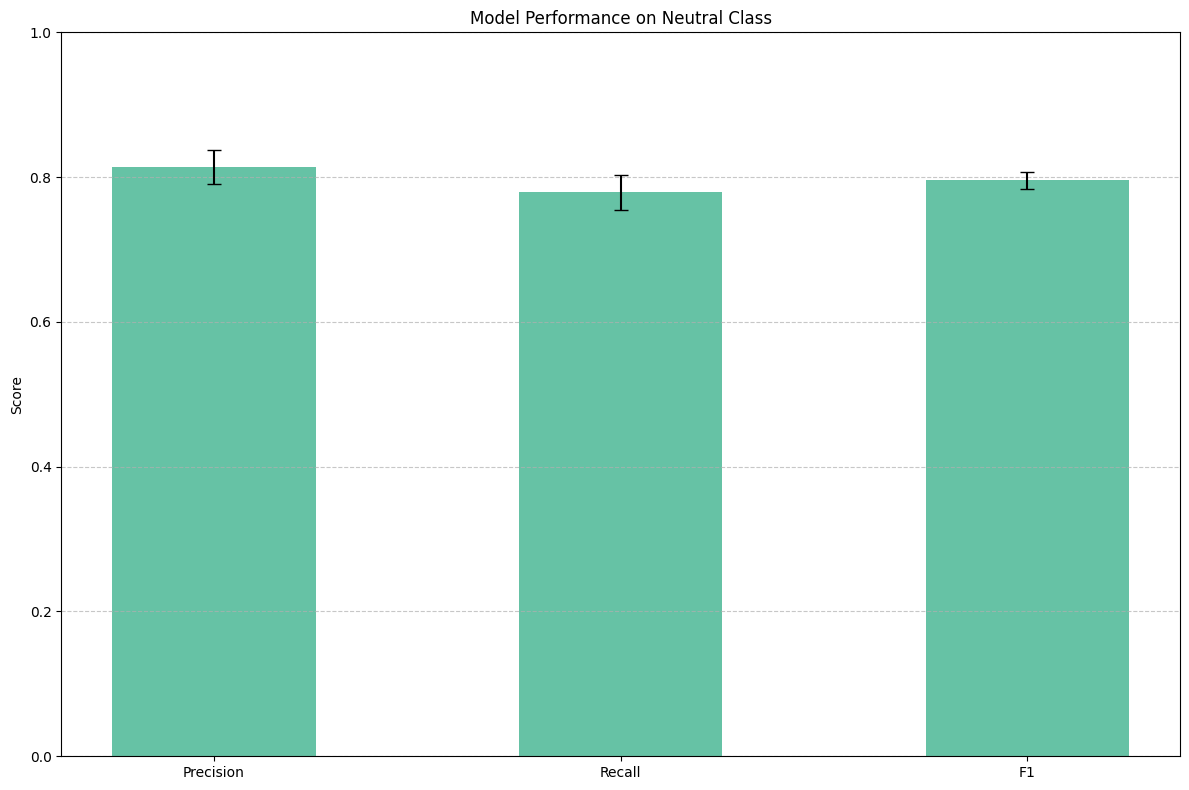

In [11]:
within_metric_barplot(
    eval_results=nli_results,
    focus_metrics=["neutral"],
    metric_title_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# within_metric_dotplot(
#     eval_results=nli_results,
#     focus_metrics=["neutral"],
#     metric_title_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=0.3,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )

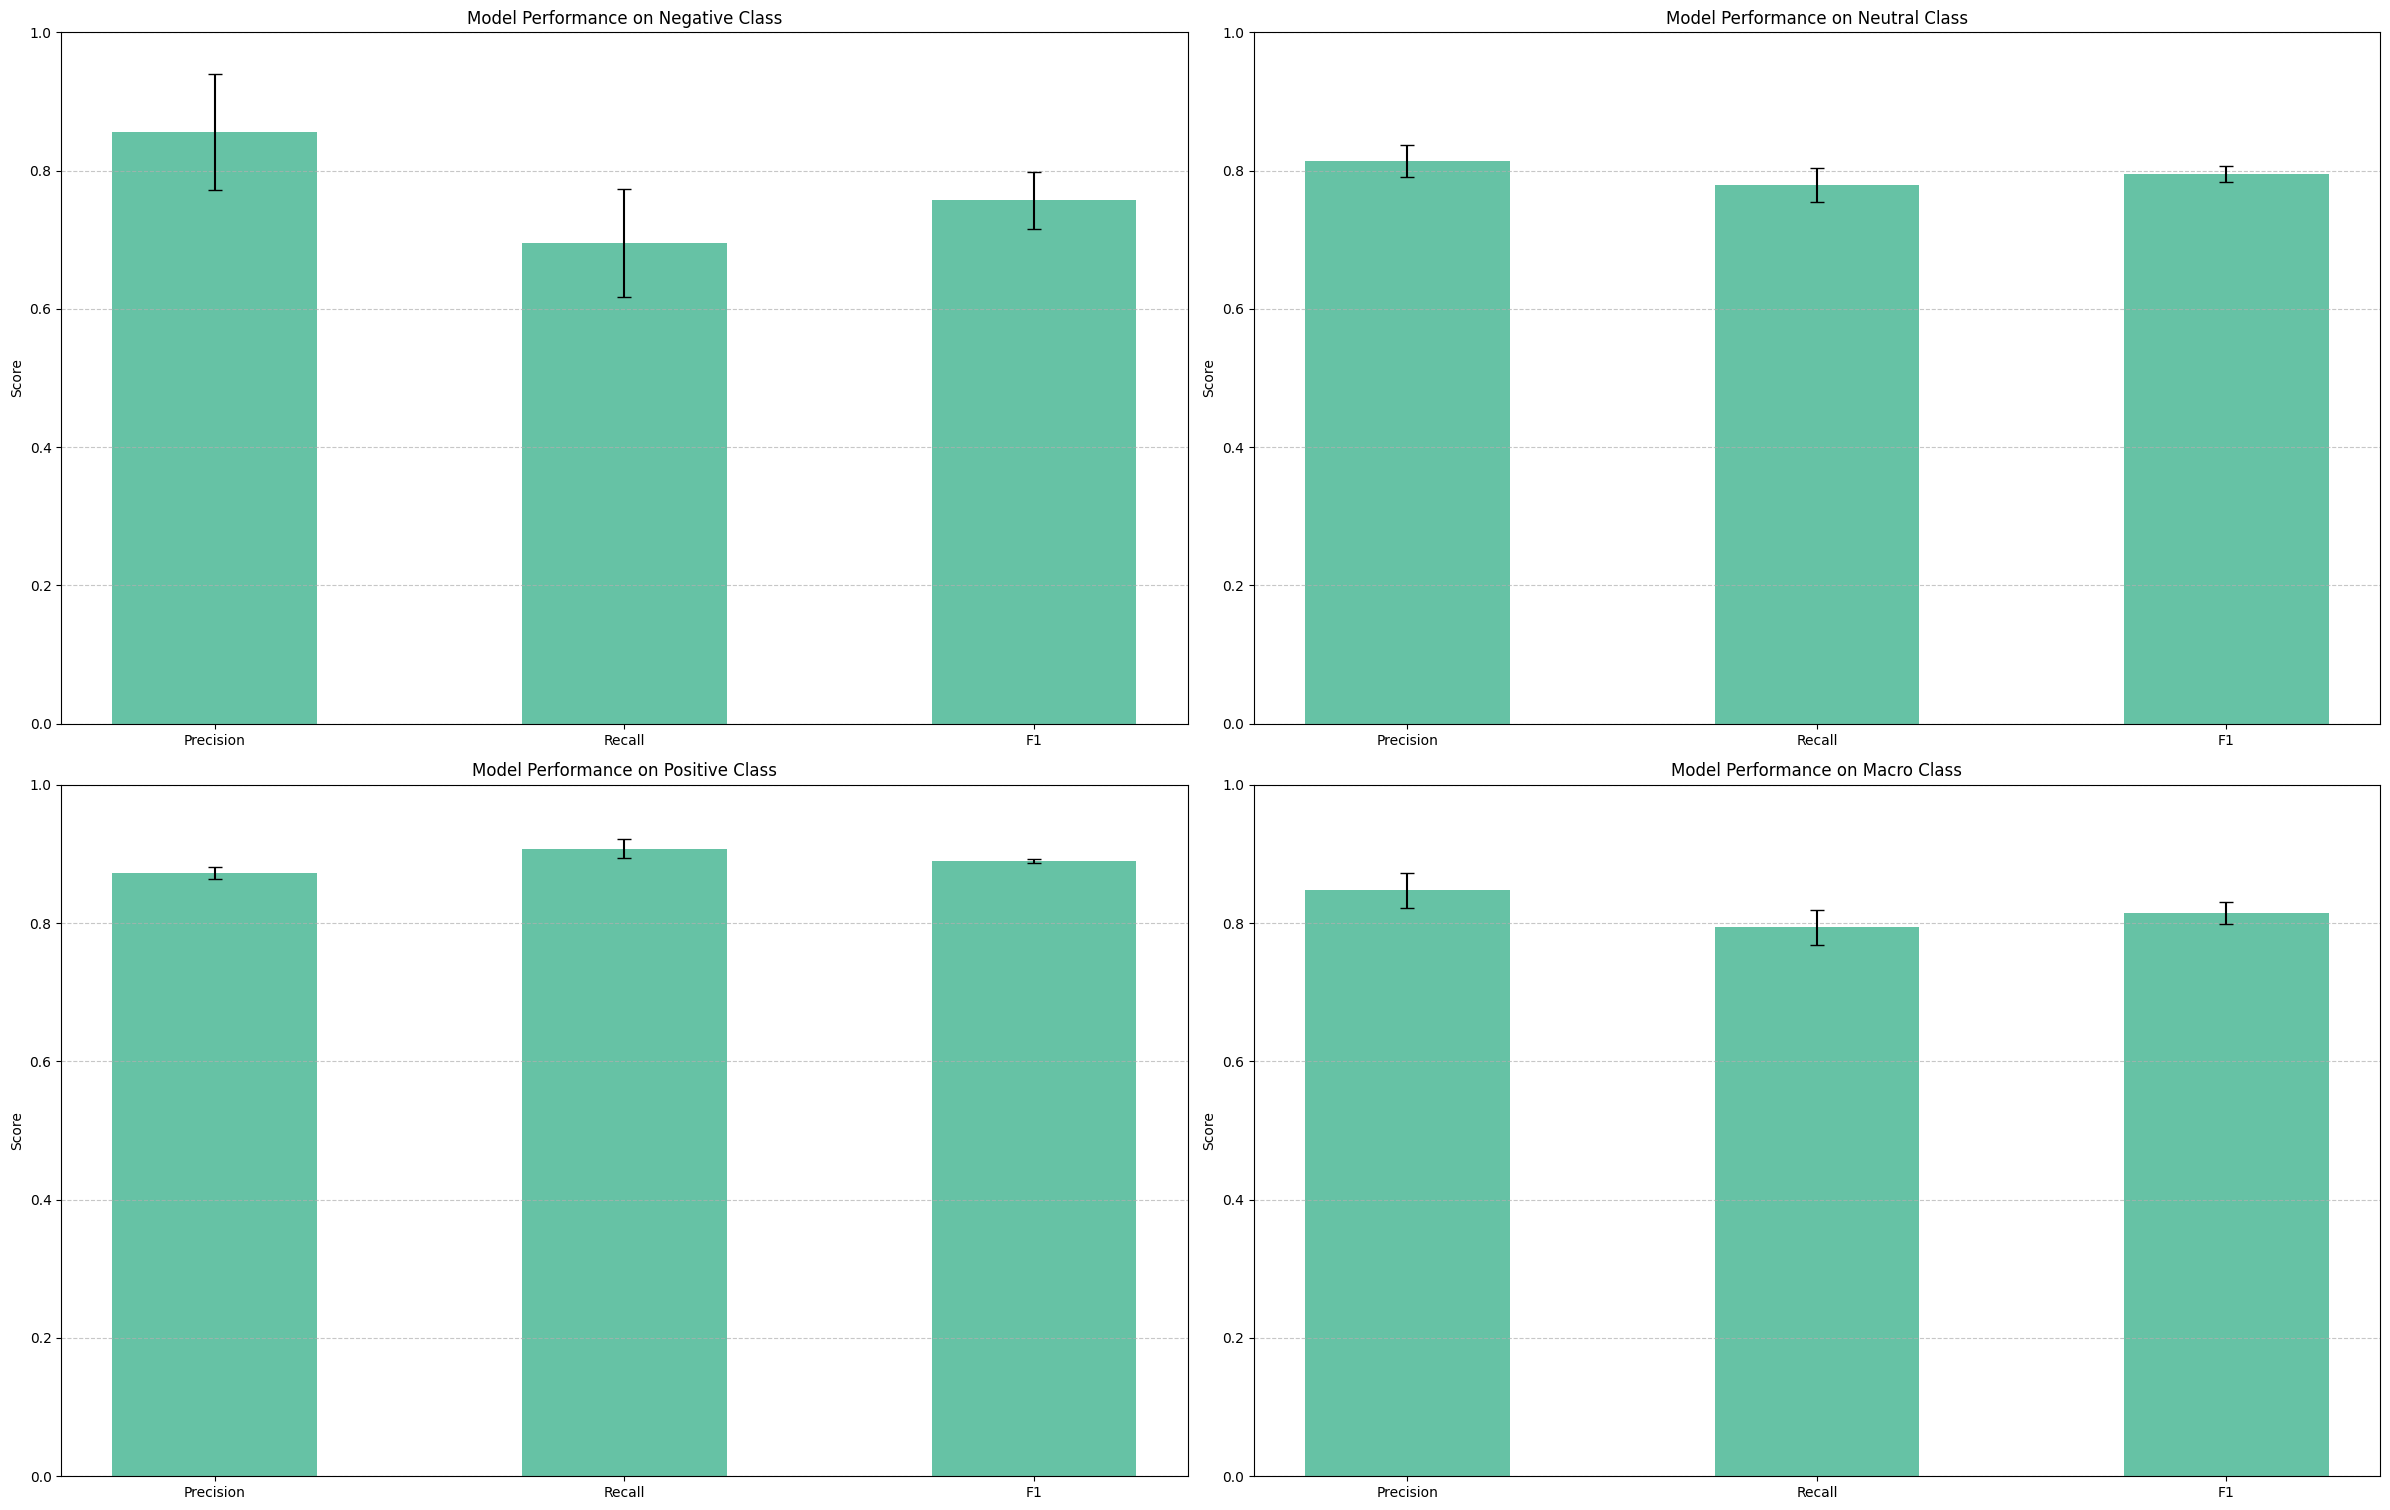

In [12]:
multi_within_metric_barplot(
    eval_results=nli_results,
    focus_metrics=focus_metrics,
    metric_title_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# multi_within_metric_dotplot(
#     eval_results=nli_results,
#     focus_metrics=focus_metrics,
#     metric_title_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=1,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )

## **Generative Models**

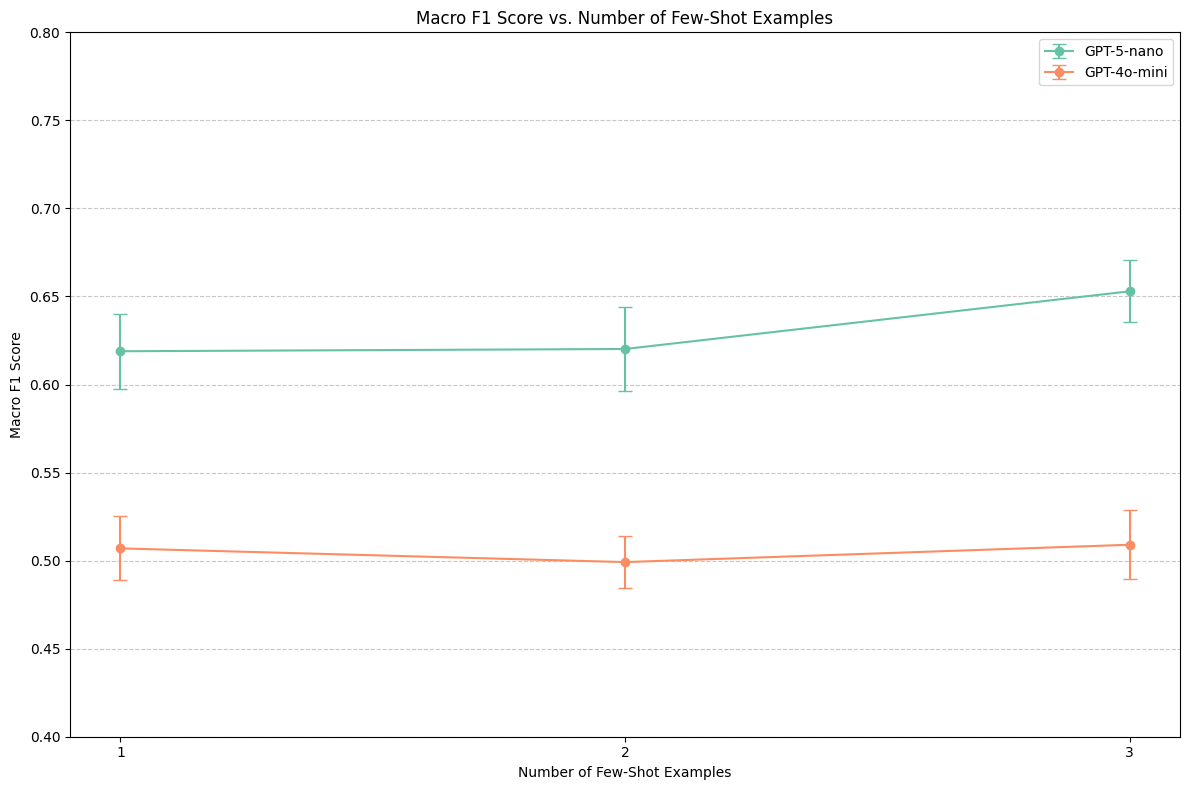

In [13]:
few_shot_dev(
    eval_results=gpt_results,
    focus_metrics=["macro"],
    comparison_metric="f1",
    main_metrics_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0.4, 0.8]
)  

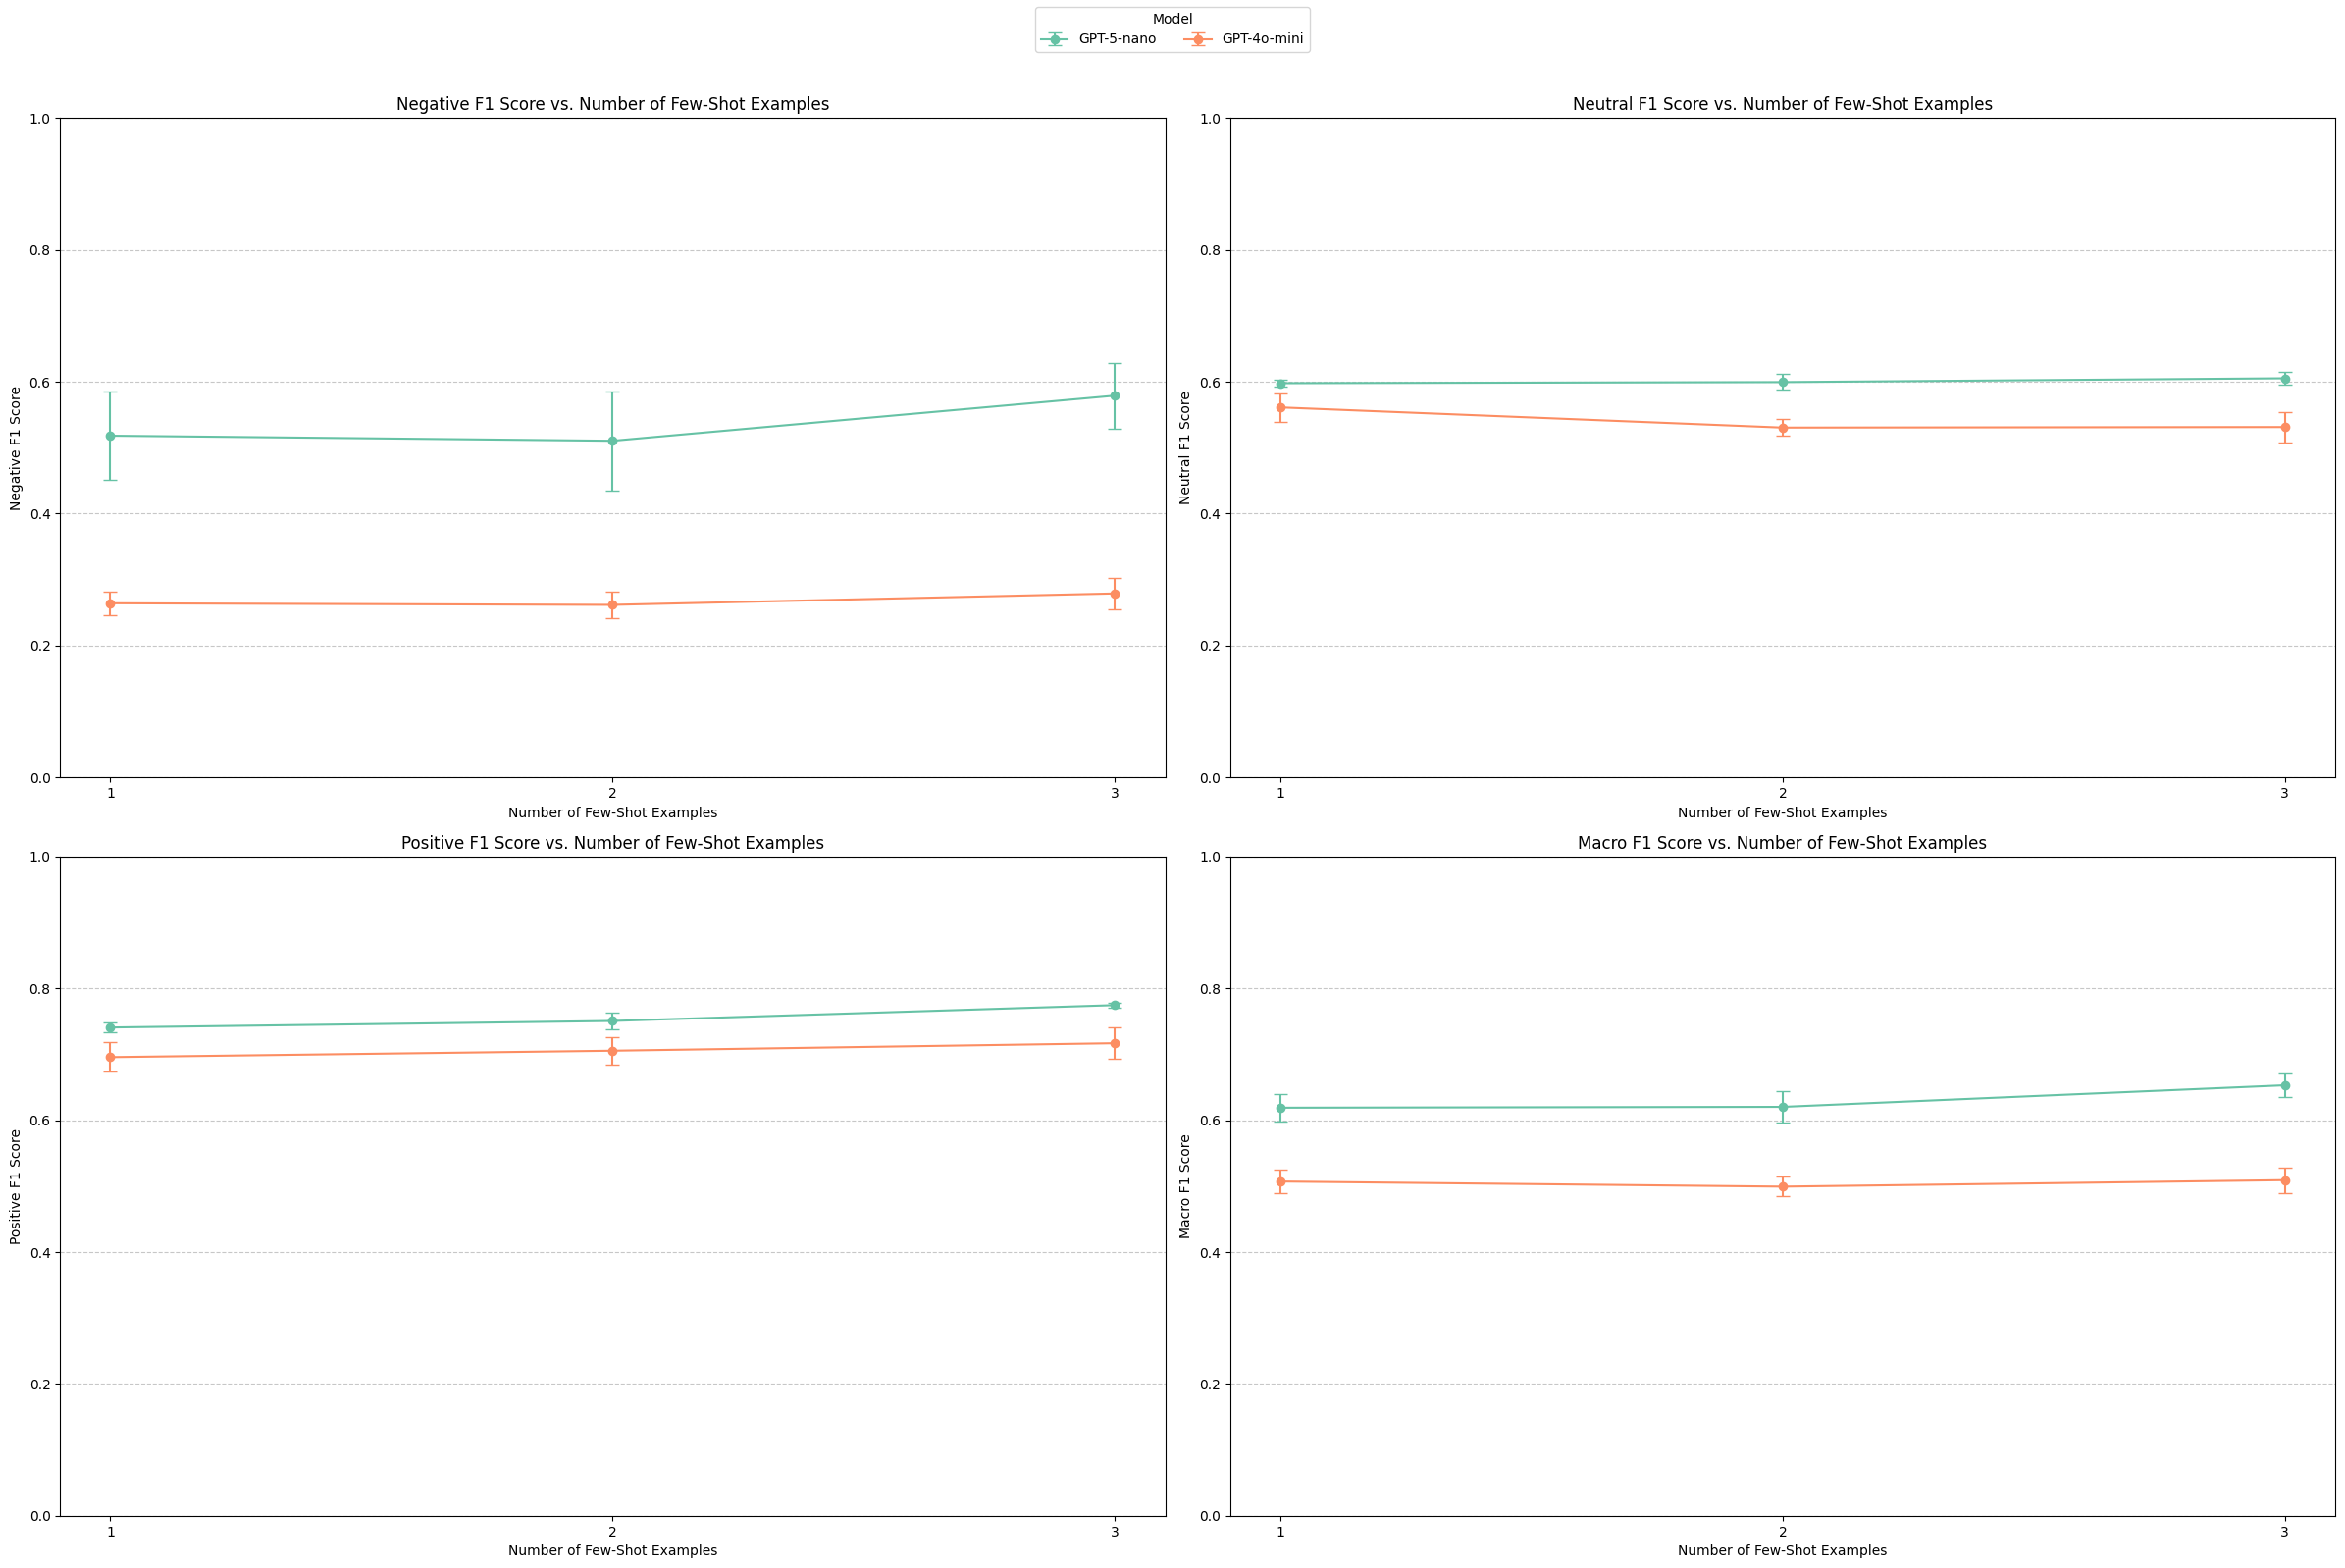

In [14]:
multi_few_shot_dev(
    eval_results=gpt_results,
    focus_metrics=focus_metrics,
    comparison_metric="f1",
    main_metrics_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1]
) 

In [15]:
# store the best version of each model family
best_gen_llm = {"gpt-5-nano": {},
                "gpt-4o-mini": {}}

for method in gpt_results:
    best_macro_f1 = 0
    best_num_few_shot = None
    for num_few_shot in gpt_results[method]:
        macro_f1_score = gpt_results[method][num_few_shot]["macro"]["f1"]["mean"]
        if macro_f1_score > best_macro_f1:
            best_num_few_shot = num_few_shot
            best_macro_f1 = macro_f1_score
    best_gen_llm[method] = gpt_results[method][best_num_few_shot]
    print(f"Model: {method}")
    print(f"Best performance with {int(best_num_few_shot.split("_")[0])} few-shot examples")
    print(f"Best seqeval score: {best_macro_f1:.4f}")
    print("-"*50)

Model: gpt-5-nano
Best performance with 3 few-shot examples
Best seqeval score: 0.6529
--------------------------------------------------
Model: gpt-4o-mini
Best performance with 3 few-shot examples
Best seqeval score: 0.5090
--------------------------------------------------


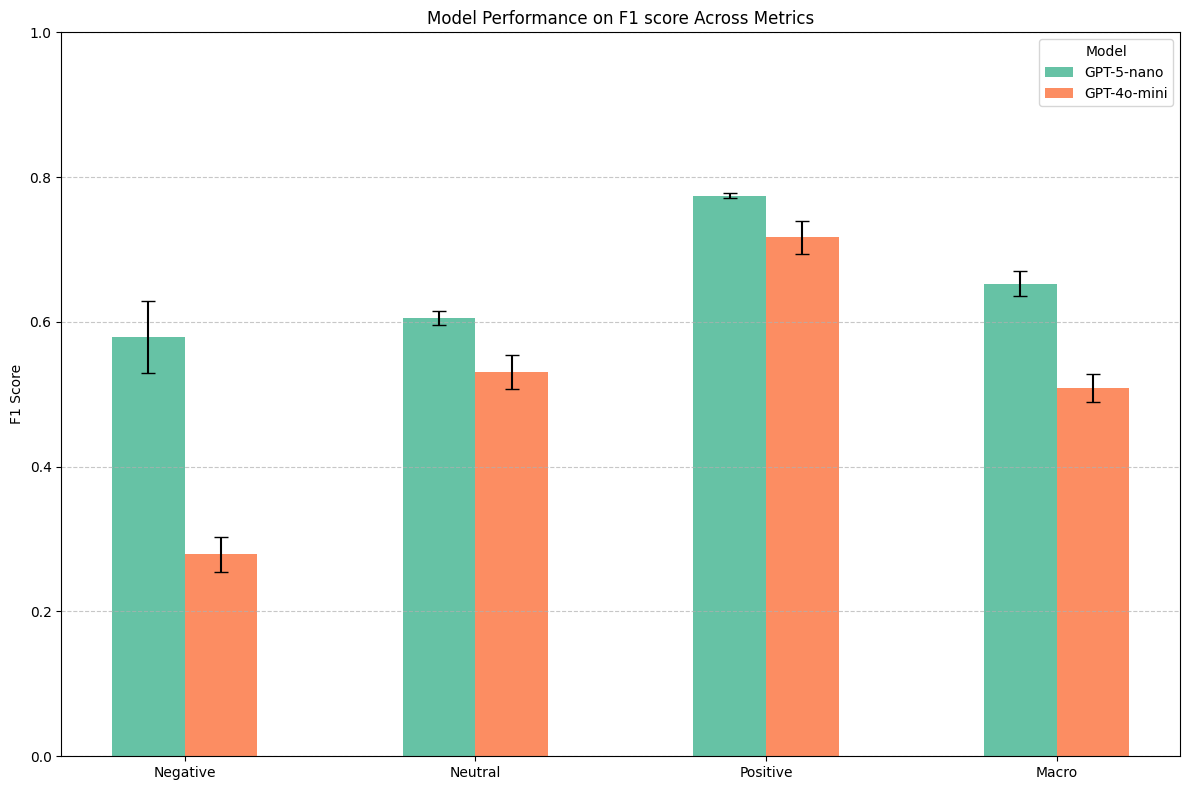

In [16]:
across_metric_barplot(
    eval_results=best_gen_llm,
    focus_metrics=focus_metrics,
    comparison_metric="f1",
    main_metrics_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# across_metric_dotplot(
#     eval_results=best_gen_llm,
#     focus_metrics=focus_metrics,
#     comparison_metric="f1",
#     main_metrics_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=0.3,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )

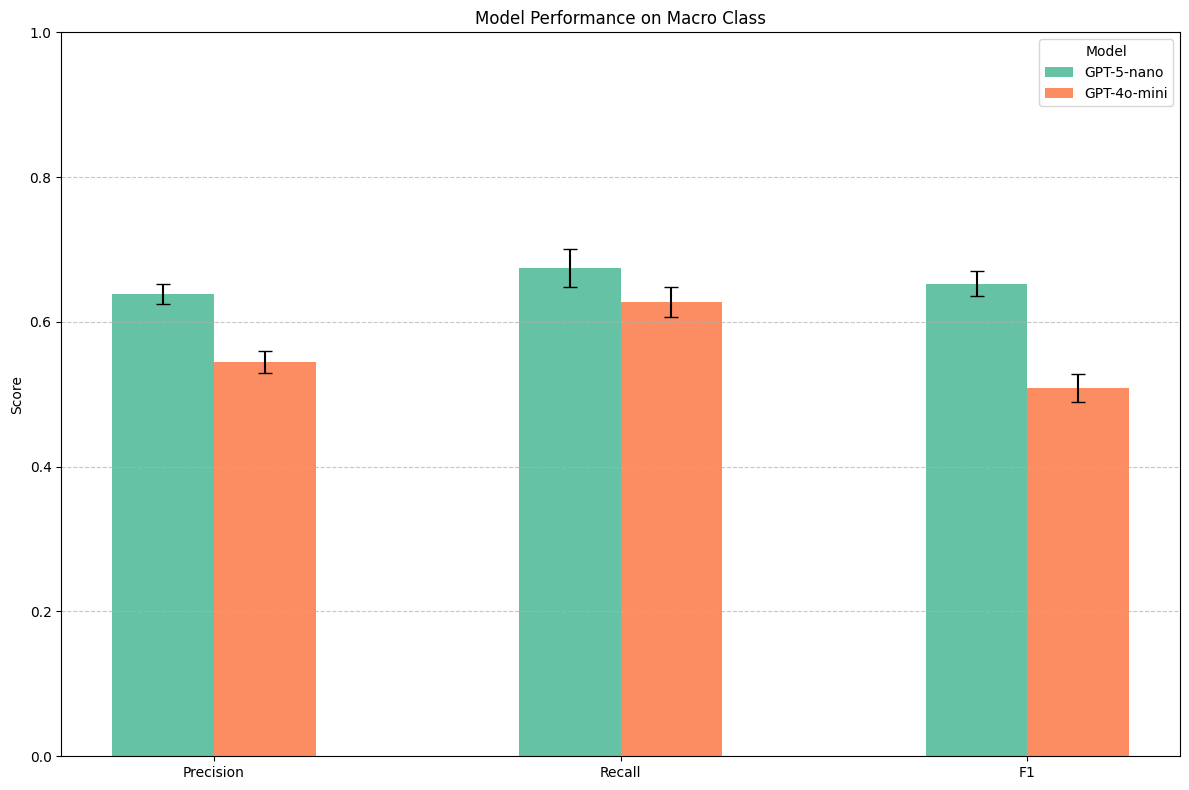

In [17]:
within_metric_barplot(
    eval_results=best_gen_llm,
    focus_metrics=["macro"],
    metric_title_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# within_metric_dotplot(
#     eval_results=best_gen_llm,
#     focus_metrics=["macro"],
#     metric_title_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=0.3,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )

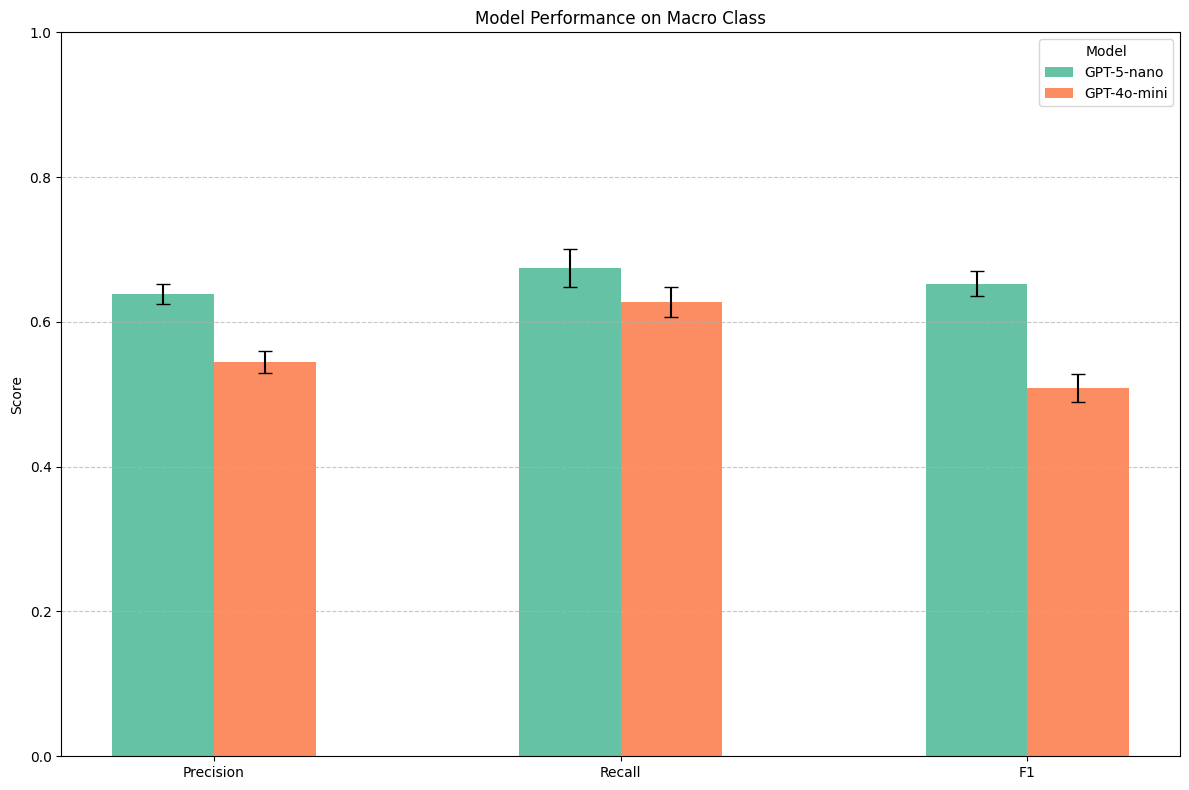

In [18]:
within_metric_barplot(
    eval_results=best_gen_llm,
    focus_metrics=["macro"],
    metric_title_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# within_metric_dotplot(
#     eval_results=best_gen_llm,
#     focus_metrics=["macro"],
#     metric_title_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=0.3,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )

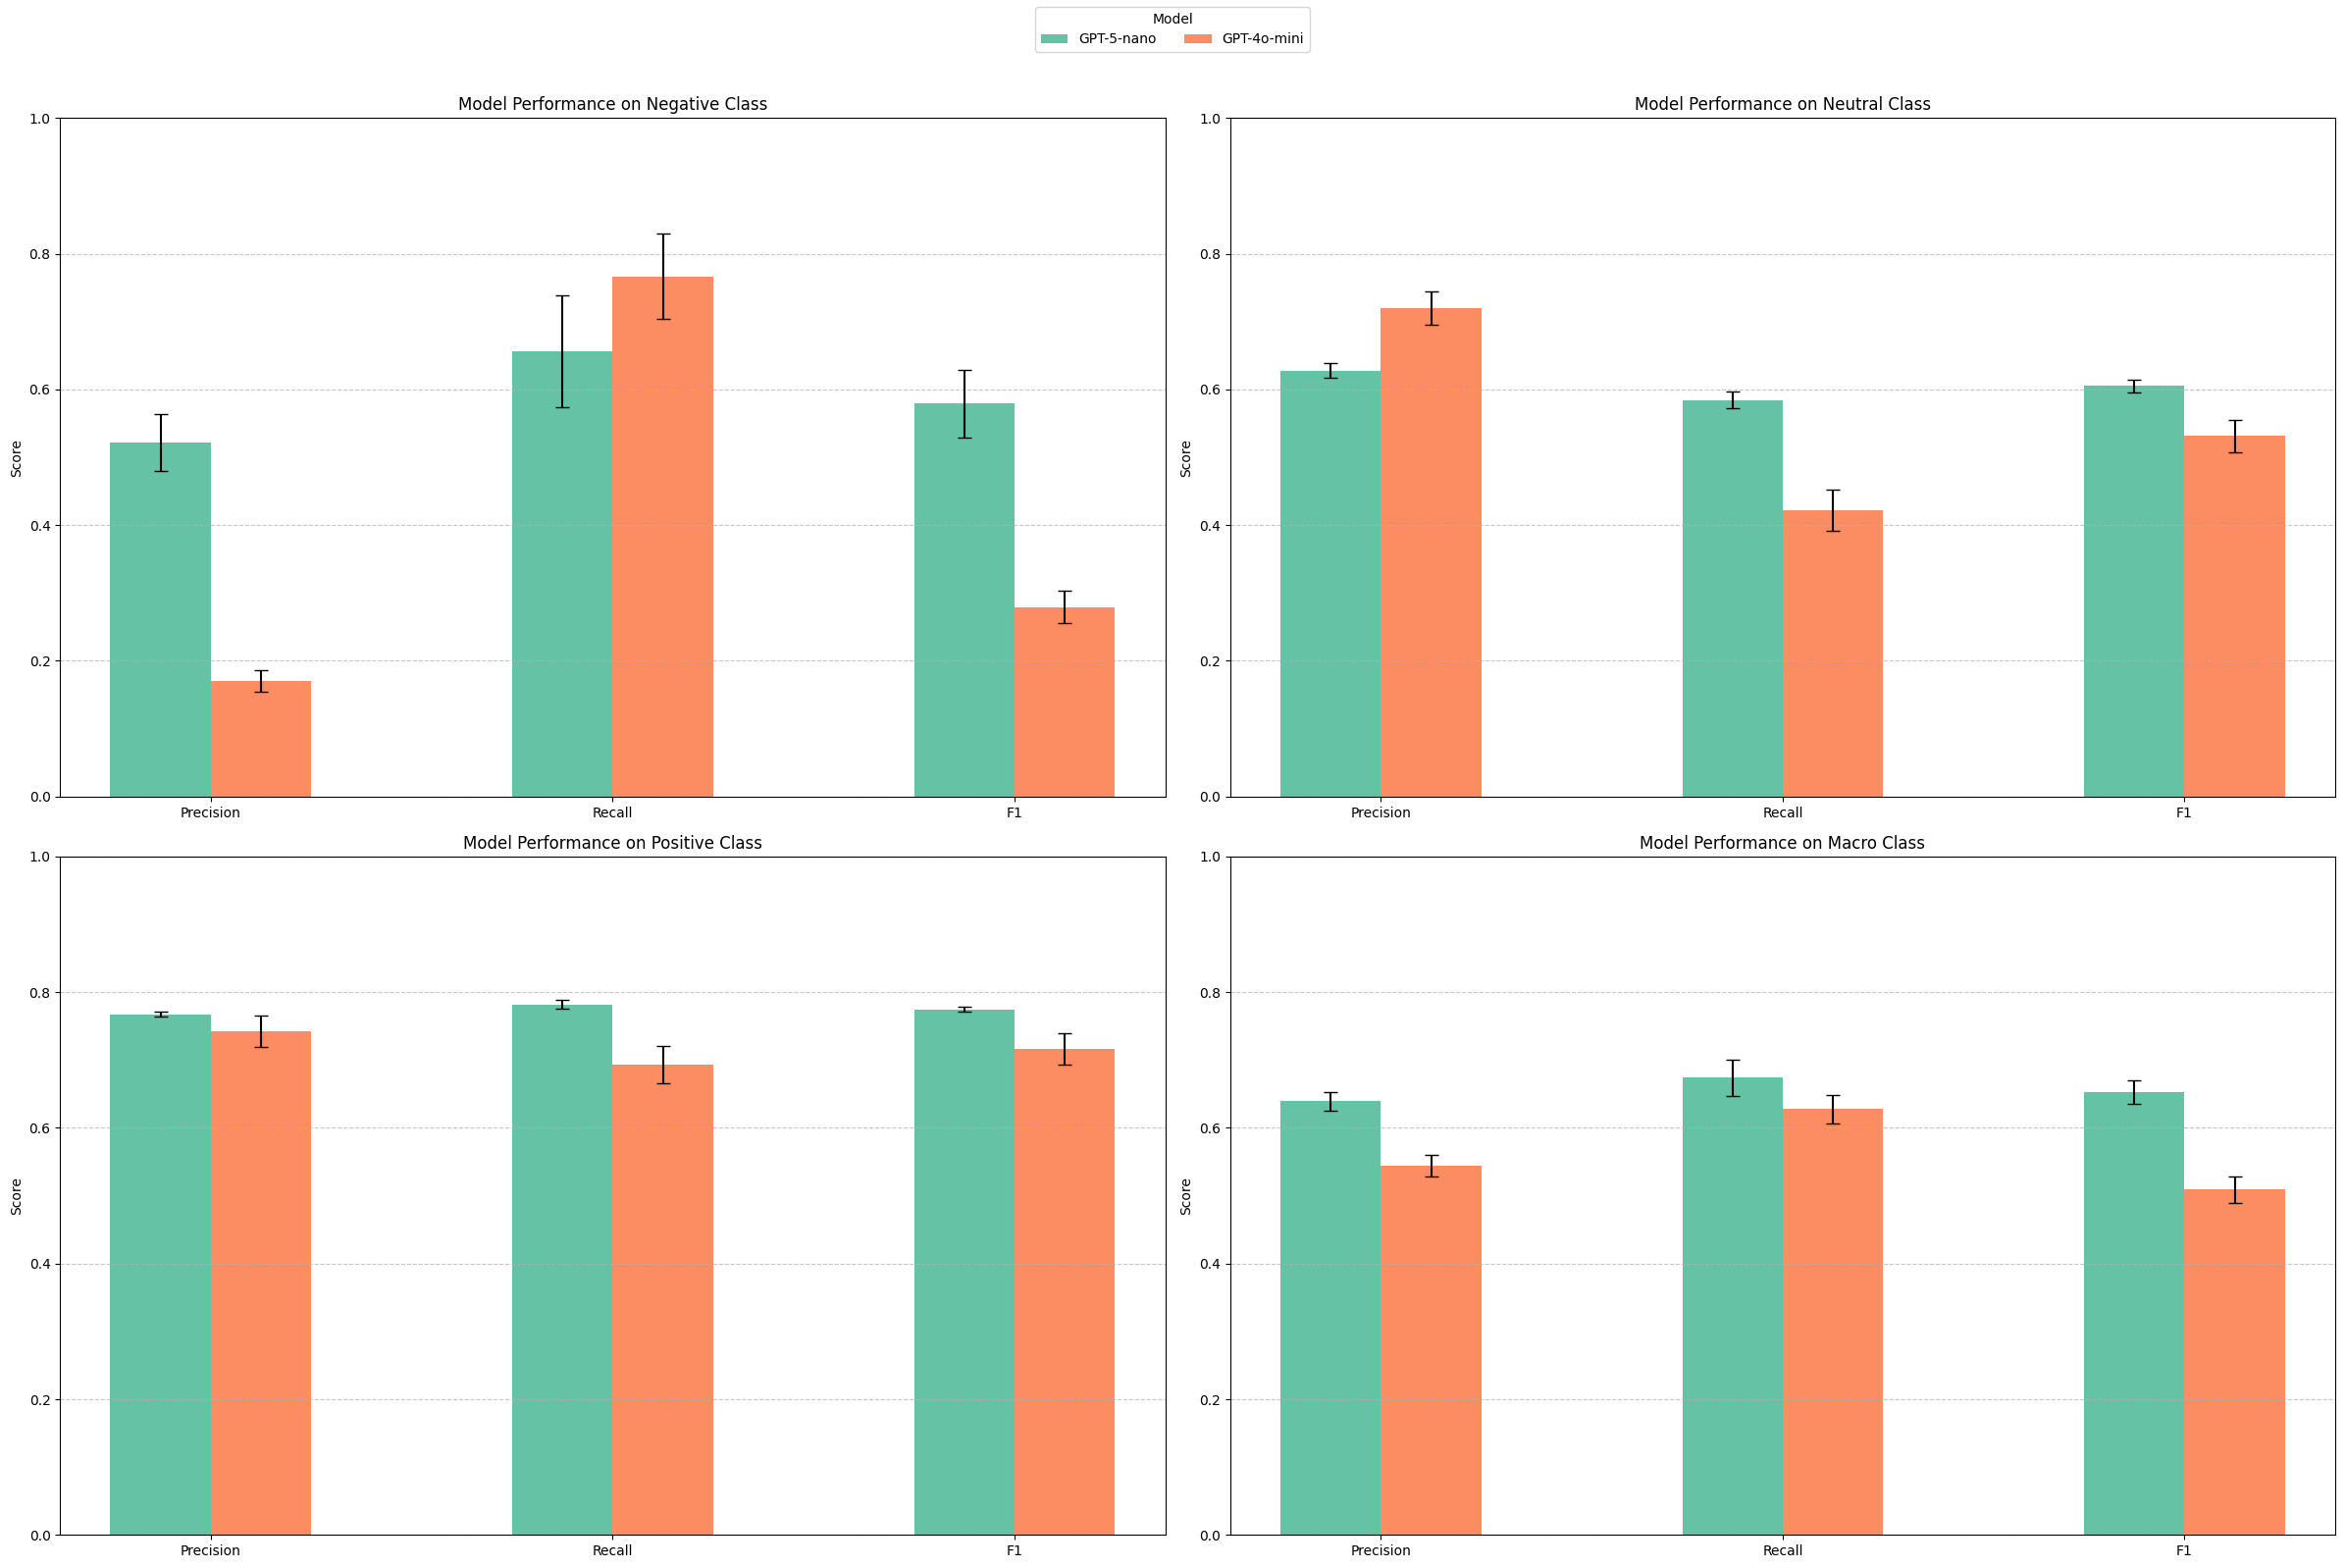

In [19]:
multi_within_metric_barplot(
    eval_results=best_gen_llm,
    focus_metrics=focus_metrics,
    metric_title_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# multi_within_metric_dotplot(
#     eval_results=best_gen_llm,
#     focus_metrics=focus_metrics,
#     metric_title_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=1,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )

# **Model Comparison Across Model Groups**

In [20]:
def find_best_model(eval_results):

    best_macro_f1 = 0
    model_name = None

    for model, eval_dict in eval_results.items():
        macro_f1 = eval_dict["macro"]["f1"]["mean"]
        if macro_f1_score > best_macro_f1:
            best_macro_f1 = macro_f1
            model_name = model
    
    return model_name

all_model_families = [nli_results, bert_results, best_gen_llm, dictionary_results]

best_models_each = {}

for model_family in all_model_families:
    best_model_name = find_best_model(model_family)
    best_models_each[best_model_name] = model_family[best_model_name]

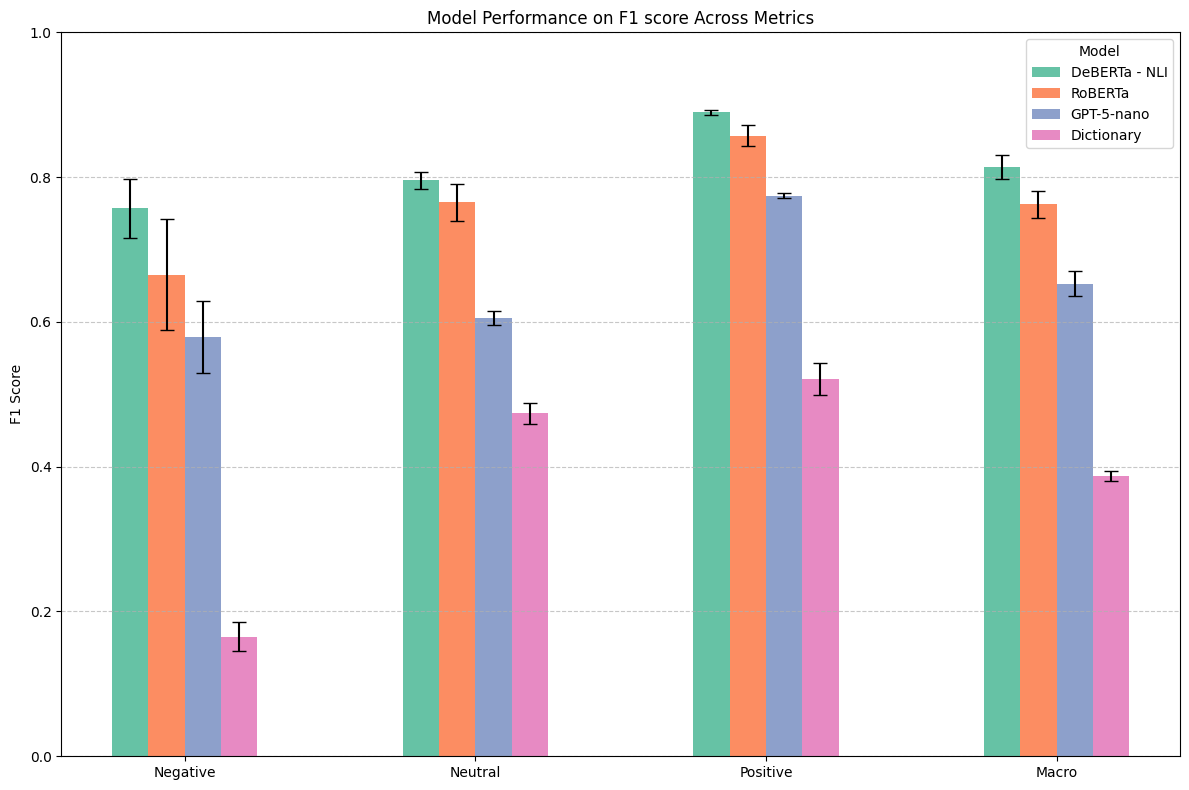

In [21]:
across_metric_barplot(
    eval_results=best_models_each,
    focus_metrics=focus_metrics,
    comparison_metric="f1",
    main_metrics_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# across_metric_dotplot(
#     eval_results=best_models_each,
#     focus_metrics=focus_metrics,
#     comparison_metric="f1",
#     main_metrics_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=0.3,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )

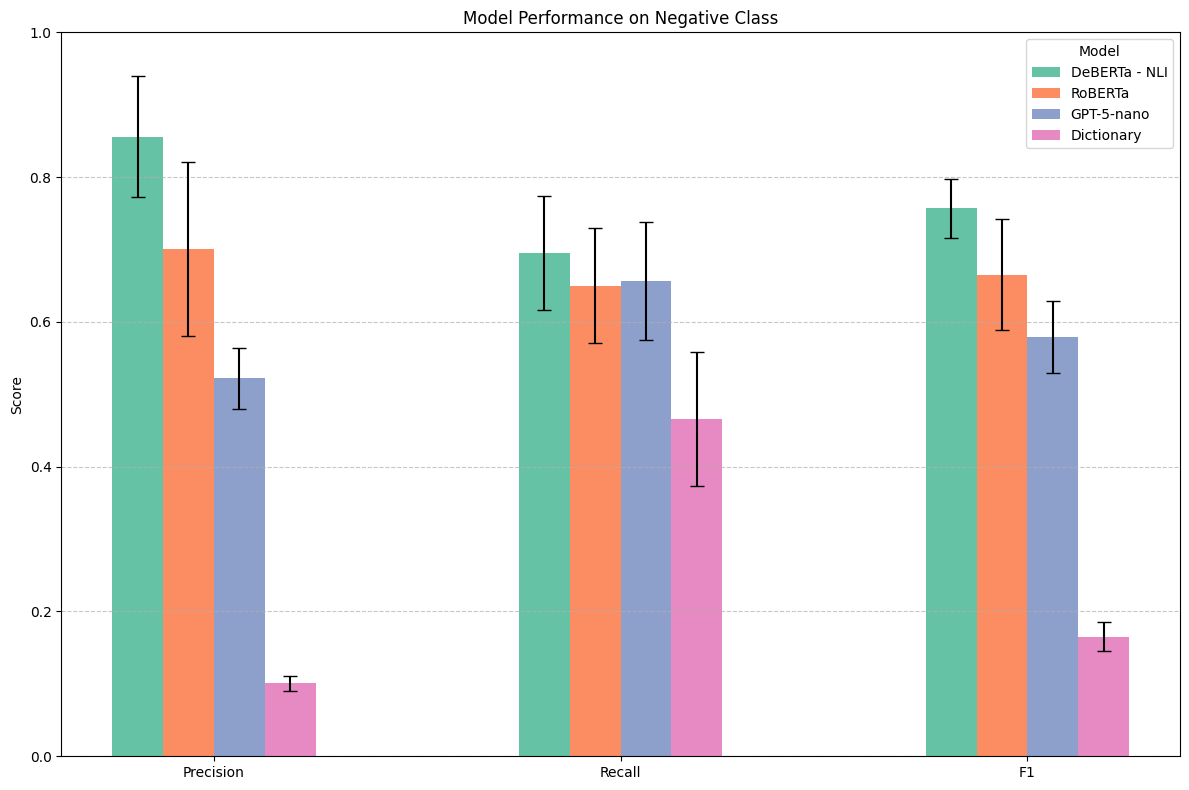

In [22]:
within_metric_barplot(
    eval_results=best_models_each,
    focus_metrics=["negative"],
    metric_title_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# within_metric_dotplot(
#     eval_results=best_models_each,
#     focus_metrics=["negative"],
#     metric_title_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=0.3,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )

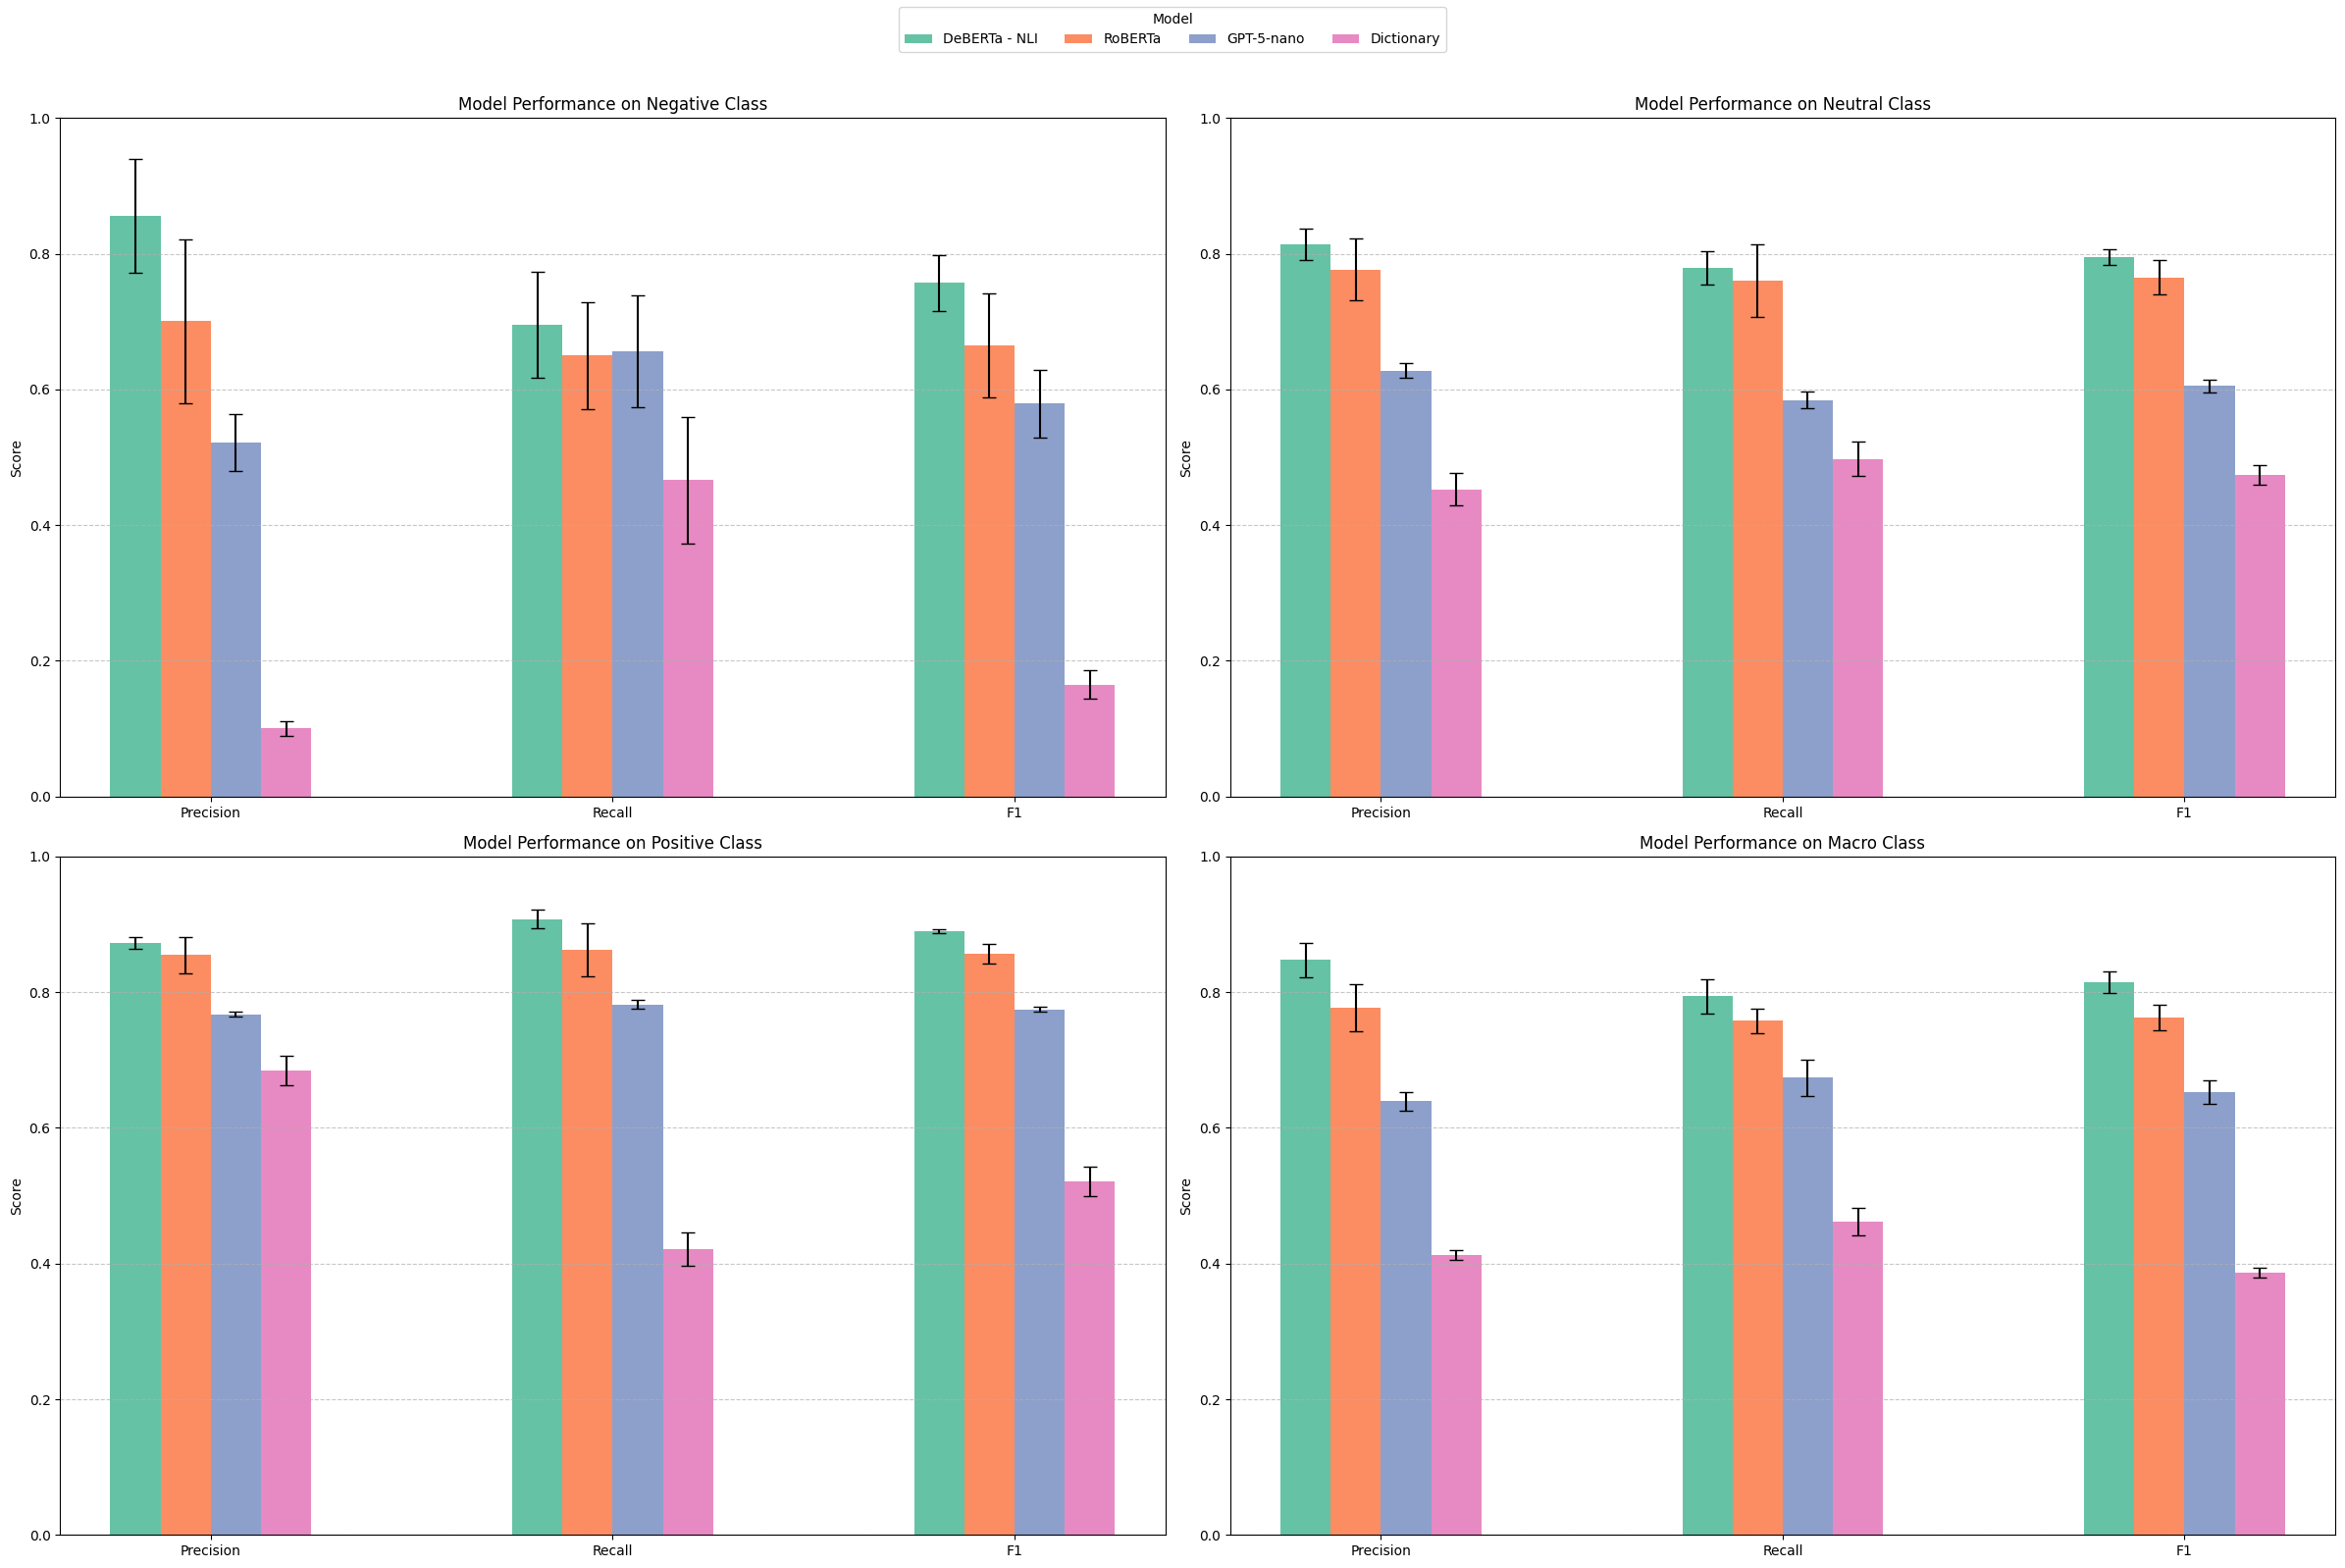

In [23]:
multi_within_metric_barplot(
    eval_results=best_models_each,
    focus_metrics=focus_metrics,
    metric_title_remap=main_metrics_remap,
    model_names_remap=model_names_remap,
    group_width=0.5,
    color_scheme=plt.cm.Set2.colors,
    ylim=[0, 1],
    task="stance"
)
# multi_within_metric_dotplot(
#     eval_results=best_models_each,
#     focus_metrics=focus_metrics,
#     metric_title_remap=main_metrics_remap,
#     model_names_remap=model_names_remap,
#     group_width=1,
#     color_scheme=plt.cm.Set2.colors,
#     marker="o",
#     ylim=[0, 1],
#     task="stance"
# )